# ECG Clinical Analyzer — Final End-to-End Pipeline v5 (PTB-XL, diagnostic superclasses)

Multi-label classification of the five PTB-XL diagnostic superclasses
(**CD, HYP, MI, NORM, STTC**) from clinically-grounded, hand-crafted 12-lead ECG
features, with a leak-free evaluation protocol, ablation study and SHAP analysis.

**Pipeline**

| Step | What happens |
|---|---|
| 1 | Configuration, environment check |
| 2 | Load PTB-XL metadata, clean it, explore it |
| 3 | Build superclass labels (order taken from the binariser, never typed by hand) |
| 4 | Waveform loading + visual check of R-peak / P-QRS-T delineation |
| 5 | Feature extraction functions (rhythm, intervals, per-lead clinical criteria, morphology, spectrum) |
| 6 | Single-record sanity check against physiological ranges |
| 7 | Parallel, chunked, **resumable** extraction over all records |
| 8 | Feature-matrix assembly and feature EDA |
| 9 | Official patient-disjoint split (`strat_fold` 1–8 / 9 / 10) |
| 10 | Leak-free preprocessing pipeline (fit on training folds only) |
| 11 | Models: Logistic Regression, Random Forest, XGBoost |
| 12 | Evaluation: macro AUC + patient-level bootstrap CI, Fmax, per-class table, confusion matrices |
| 13 | Ablation over feature blocks |
| 14 | SHAP explainability and agreement with textbook ECG criteria |
| 15 | Save deployable bundle, inference function, run summary for the report |

**Corrections made in this version** (on top of the earlier "corrected" notebook)

| # | Problem | Fix |
|---|---|---|
| 1 | Best model was chosen by **test-fold** AUC (selection leakage) | Selected on the **validation fold (9)**; test fold 10 is only reported |
| 2 | `pos_weight` was computed for XGBoost but never passed to it | Custom `XGBMultiLabel` applies per-class `scale_pos_weight` |
| 3 | `np.trapezoid` fails on NumPy < 2.0 | `scipy.integrate.trapezoid` |
| 4 | PTB-XL stores ages > 89 as `300` (sentinel) | Replaced by 90 before any use |
| 5 | "Fmax" was actually micro-F1 | CAFA-style **sample-centric** Fmax, as used in the PTB-XL benchmark |
| 6 | Bootstrap CI resampled records, but records of one patient are correlated | **Patient-level (cluster) bootstrap** |
| 7 | Q/S amplitudes could have the wrong sign (Q>0 when no Q wave); R/S and Q/R ratios exploded for tiny denominators; Python `max()` on NaN | Q ≤ 0, S ≤ 0, R ≥ 0; denominators floored; NaN-safe helpers |
| 8 | ΔRR was computed across removed (non-physiological) RR intervals | ΔRR only between adjacent valid RRs |
| 9 | QRS axis from R+S amplitudes | Axis from **net QRS area** in I and aVF (+ sin/cos for circularity) |
| 10 | Serial extraction (~1 h) with no checkpoint: a crash loses everything | Parallel, chunked, resumable; fallback detection leads (II → I → V5) |
| 11 | Lead order assumed | Verified against the WFDB header for every record |
| 12 | Model selection / thresholds / bundle used loosely-scoped variables (`ths` reused) | Thresholds stored per model; bundle saved as one dict |
| 13 | Heavy-tailed ratio features hurt linear models | Train-fit 0.5/99.5 percentile clipping + missingness filter inside the pipeline |
| 14 | Demographics mixed into the "ECG" model | Off by default; reported as a separate ablation row |
| 15 | No EDA / no visual validation of the delineation | Added: metadata EDA, label co-occurrence, waveform + fiducial plots, feature sanity plots, confusion matrices |

**Corrections made in this version (v5)** — found by auditing the first full run of the previous notebook

| # | Problem found in the run output | Fix |
|---|---|---|
| 16 | **QRS duration was inflated** (median 142 ms; only 14 % of records inside 70-110 ms; a NORM record measured 176 ms / axis −58°). The DWT QRS onset/offset on a single lead is unreliable, and it also contaminated the QRS-area axis, the J-point/ST measurements and the CD features (`intv_qrs` ranked only #14 for CD) | QRS onset/offset are now taken from the **12-lead spatial velocity** (`refine_qrs_bounds`): the QRS ends where the vector velocity falls below 12 % of its peak and stays there for 10 ms. DWT limits are kept only as a per-beat fallback, and the share of refined beats is a feature (`intv_qrs_refined_frac`). A plausibility check on **NORM-only** records is added so a broken extractor is caught before modelling |
| 17 | The "precision-targeted" policy **lowered** thresholds whenever the F1-optimal recall was below the floor, which *reduced* precision (HYP 0.482 → 0.468, CD 0.762 → 0.680, MI 0.739 → 0.698) | A precision-targeted threshold is now **never below the F1-optimal one**: it is the highest threshold that still keeps recall ≥ the floor (default 0.70, optional per-class override). It can only make a class more conservative, never less |
| 18 | The classifier chain's inner out-of-fold probabilities were produced by **record-level** folds, so one patient could sit on both sides of an inner split (optimistic probabilities) | Inner folds are **patient-grouped** (`StratifiedGroupKFold` on `patient_id`) |
| 19 | The chain was selected on a validation edge of 0.0008 macro AUC although it is ~4.5x slower than plain XGBoost and its test AUC was not better | **Selection with a tolerance**: the simplest model within `SELECTION_TOL` (0.003) of the best validation macro AUC wins |
| 20 | SHAP and the seed study ran on plain XGBoost, not on the model that is actually saved | SHAP and the seed study now use the **selected** model (chain-position probability columns are shown as `chain_prob_*`); the seed study also reports the spread of precision / recall / F1 |
| 21 | HYP (which includes atrial enlargement as well as ventricular hypertrophy) was served by voltage criteria only; HYP precision stayed below 0.5 | New **P-wave block** (`pwave_`: duration, amplitude in II and V1, terminal P force in V1) and extra voltage criteria (Gubner, RVH index, Peguero-Lo Presti) |
| 22 | Accuracy was never reported | Per-label **accuracy** and **balanced accuracy**, macro / micro precision, recall and exact-match accuracy are reported and saved to `headline_metrics.json` |

> **Feature extraction must be re-run** (`FEATURE_VERSION = "v5.0"` writes to a new cache folder): the QRS limits changed, so every cached v4 feature is stale. Expect roughly one hour on a laptop.

> **Cache note.** Feature extraction is the slow step. Results are cached per chunk under
> `CACHE_DIR`. If you change *any* feature function, bump `FEATURE_VERSION` in the next cell
> (or set `FORCE_EXTRACT = True`) so stale features are never reused.

**Enhancements added on top of the corrections above** (raising accuracy/precision, not fixing bugs)

| # | Gap identified from the first full run's own diagnostics | What was added |
|---|---|---|
| 1 | HYP precision was only 0.48 at the F1-optimal threshold: the F1 criterion tolerates a lot of false positives on a rare class | A **precision-targeted threshold policy** (`THRESHOLD_POLICY = "precision_target"`): per class, the highest threshold that keeps recall $\ge$ `RECALL_FLOOR`, **never below the F1-optimal threshold** (v5 fix: the first version could lower a threshold and lose precision). Both policies are computed and reported side by side. |
| 2 | ~24% of records carry 2+ labels, but one-vs-rest models never see a class's own prediction when scoring another class | A **probabilistic classifier chain** (`XGBClassifierChain`): one per-label XGBoost, fit in rarest-first order, each one receiving the *out-of-fold, patient-grouped* predicted probabilities of the labels already placed earlier in the chain as extra input columns (never in-sample predictions, to avoid leakage). At inference the chain reuses its own earlier-stage probabilities the same way. |

## 0. Environment

In [1]:
# Run once in a terminal / a notebook cell if something is missing:
# pip install numpy pandas scipy scikit-learn matplotlib seaborn wfdb neurokit2 xgboost shap joblib tqdm
# Recent versions of all of these are expected to work; if a cell raises a version error, run pip install -U <package>.

In [2]:
import os, sys, ast, json, time, platform, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import wfdb
import neurokit2 as nk
import sklearn
from joblib import Parallel, delayed
from scipy.integrate import trapezoid
from scipy.signal import butter, sosfiltfilt
from tqdm.auto import tqdm

# Only silence nan-on-empty-slice noise; real problems must stay visible.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")

print("Python      :", sys.version.split()[0], "|", platform.system())
print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("NeuroKit2   :", nk.__version__)
print("WFDB        :", wfdb.__version__)

Python      : 3.14.0 | Windows
NumPy       : 2.4.3
Pandas      : 2.3.3
scikit-learn: 1.8.0
NeuroKit2   : 0.2.13
WFDB        : 4.3.1


In [3]:
# ----------------------------------------------------------------
# Paths
# ----------------------------------------------------------------
DATA_DIR        = "../data/ptb-xl"          # folder that contains ptbxl_database.csv
FEATURE_VERSION = "v5.0"                    # bump when ANY feature function changes
OUTPUT_DIR      = "../outputs/v5_final"

DATABASE_PATH = os.path.join(DATA_DIR, "ptbxl_database.csv")
SCP_PATH      = os.path.join(DATA_DIR, "scp_statements.csv")
CACHE_DIR     = os.path.join(OUTPUT_DIR, f"cache_{FEATURE_VERSION}")
FIG_DIR       = os.path.join(OUTPUT_DIR, "figures")
TABLE_DIR     = os.path.join(OUTPUT_DIR, "tables")
SHAP_DIR      = os.path.join(OUTPUT_DIR, "shap")
for d in (OUTPUT_DIR, CACHE_DIR, FIG_DIR, TABLE_DIR, SHAP_DIR):
    os.makedirs(d, exist_ok=True)

# ----------------------------------------------------------------
# Experiment settings
# ----------------------------------------------------------------
SAMPLING_RATE    = 500        # uses filename_hr (500 Hz records)
RANDOM_STATE     = 42
MIN_LIKELIHOOD   = 0          # SCP-code likelihood threshold (0 = PTB-XL benchmark convention)
USE_DEMOGRAPHICS = False      # True adds age/sex to the MAIN model (they are always tested in the ablation)
FORCE_EXTRACT    = False      # True = ignore cached feature chunks
N_JOBS           = max(1, (os.cpu_count() or 2) - 1)   # set to 1 if parallel extraction misbehaves
CHUNK_SIZE       = 1000       # records per cached chunk
ABLATION_TREES   = 200        # XGBoost trees used in the ablation runs (speed)
THRESHOLD_POLICY = "precision_target"   # "f1" (F1-optimal) or "precision_target" (highest threshold keeping recall >= floor, never below the F1 threshold)
RECALL_FLOOR    = 0.70       # used only when THRESHOLD_POLICY == "precision_target"
CHAIN_ORDER_BY   = "prevalence"         # classifier chain is ordered rarest-class-first
RECALL_FLOOR_BY_CLASS = {}              # optional per-class recall floor, e.g. {"HYP": 0.65}
SELECTION_TOL    = 0.003      # a simpler model within this validation macro AUC of the best one is preferred

LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]
LEAD_IDX   = {n: i for i, n in enumerate(LEAD_NAMES)}
DETECTION_LEADS = ["II", "I", "V5"]     # R-peak / delineation lead, in order of preference

np.random.seed(RANDOM_STATE)

for p in (DATA_DIR, DATABASE_PATH, SCP_PATH):
    assert os.path.exists(p), (
        f"Not found: {p}\n"
        "Set DATA_DIR to the folder holding ptbxl_database.csv, scp_statements.csv and records500/ "
        "(PTB-XL v1.0.3 from PhysioNet).")
print("Data folder OK :", os.path.abspath(DATA_DIR))
print("Output folder  :", os.path.abspath(OUTPUT_DIR))
print("Parallel jobs  :", N_JOBS)


def save_fig(name):
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("saved:", path)

Data folder OK : c:\Users\USER\Desktop\ECG_Clinical_Decision_Support_System\data\ptb-xl
Output folder  : c:\Users\USER\Desktop\ECG_Clinical_Decision_Support_System\outputs\v5_final
Parallel jobs  : 13


## 1. Metadata: load, clean, explore

PTB-XL metadata columns used here: `ecg_id` (index), `patient_id`, `age`, `sex`
(0 = male, 1 = female), `scp_codes` (dict as string: code → likelihood), `strat_fold`
(1–10, patient-disjoint), `filename_lr` / `filename_hr` (100 Hz / 500 Hz waveform paths) and the
signal-quality flags (`baseline_drift`, `static_noise`, `burst_noise`, `electrodes_problems`,
`extra_beats`, `pacemaker`).

In [4]:
metadata       = pd.read_csv(DATABASE_PATH, index_col="ecg_id")
scp_statements = pd.read_csv(SCP_PATH, index_col=0)

REQUIRED = ["patient_id", "age", "sex", "scp_codes", "strat_fold", "filename_lr", "filename_hr"]
absent = [c for c in REQUIRED if c not in metadata.columns]
assert not absent, f"metadata is missing columns: {absent}"

print("Metadata      :", metadata.shape)
print("SCP statements:", scp_statements.shape)
print("\nMetadata columns:\n", list(metadata.columns))
print("\nSCP columns:\n", list(scp_statements.columns))
display(metadata.head(3))

Metadata      : (21799, 27)
SCP statements: (71, 12)

Metadata columns:
 ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']

SCP columns:
 ['description', 'diagnostic', 'form', 'rhythm', 'diagnostic_class', 'diagnostic_subclass', 'Statement Category', 'SCP-ECG Statement Description', 'AHA code', 'aECG REFID', 'CDISC Code', 'DICOM Code']


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr


In [5]:
# Missingness of the metadata columns
miss = (metadata.isna().mean() * 100).round(1).sort_values(ascending=False)
print("Columns with missing values (%):")
print(miss[miss > 0].to_string())

# Age: PTB-XL encodes every age > 89 as 300 (privacy sentinel). Left as is, it wrecks any age feature.
n_sentinel = int((metadata["age"] >= 120).sum())
metadata["age"] = metadata["age"].mask(metadata["age"] >= 120, 90)      # mask (not where): genuine NaN ages stay NaN
print(f"\nAge sentinel values (>=120) replaced by 90: {n_sentinel}")
print("Age range after cleaning:", metadata["age"].min(), "-", metadata["age"].max())
print("Records / unique patients:", len(metadata), "/", metadata["patient_id"].nunique())

Columns with missing values (%):
electrodes_problems    99.9
infarction_stadium2    99.5
pacemaker              98.7
burst_noise            97.2
baseline_drift         92.7
extra_beats            91.1
static_noise           85.0
infarction_stadium1    74.3
height                 68.0
weight                 56.8
validated_by           43.0
heart_axis             38.8
nurse                   6.8
site                    0.1

Age sentinel values (>=120) replaced by 90: 293
Age range after cleaning: 2.0 - 90.0
Records / unique patients: 21799 / 18869


saved: ../outputs/v5_final\figures\01_metadata_eda.png


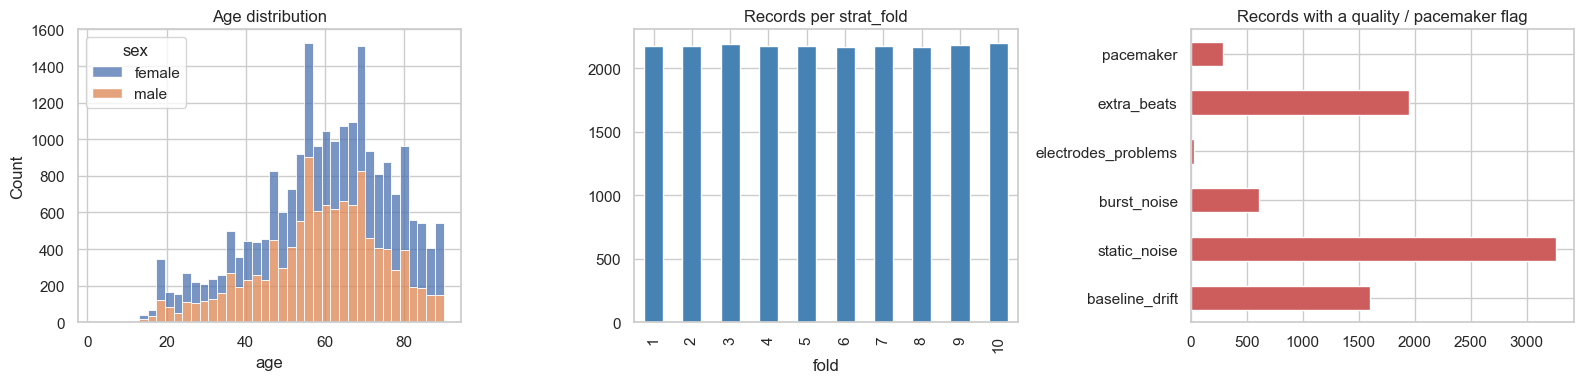

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=metadata.assign(sex=metadata["sex"].map({0: "male", 1: "female"})),
             x="age", hue="sex", bins=40, multiple="stack", ax=ax[0])
ax[0].set_title("Age distribution")

metadata["strat_fold"].value_counts().sort_index().plot.bar(ax=ax[1], color="steelblue")
ax[1].set_title("Records per strat_fold"); ax[1].set_xlabel("fold")

flags = ["baseline_drift", "static_noise", "burst_noise", "electrodes_problems", "extra_beats", "pacemaker"]
flags = [f for f in flags if f in metadata.columns]
if flags:
    pd.Series({f: int(metadata[f].notna().sum()) for f in flags}).plot.barh(ax=ax[2], color="indianred")
    ax[2].set_title("Records with a quality / pacemaker flag")
else:
    ax[2].axis("off")

plt.tight_layout(); save_fig("01_metadata_eda.png"); plt.show()

## 2. Labels: SCP codes → diagnostic superclasses

Only statements flagged `diagnostic == 1` are mapped, each to its `diagnostic_class`
(NORM, MI, STTC, CD, HYP). Records with no diagnostic statement are removed.

In [7]:
metadata["scp_codes"] = metadata["scp_codes"].apply(ast.literal_eval)

diagnostic_scp = scp_statements[scp_statements["diagnostic"] == 1]
DIAG_MAP = diagnostic_scp["diagnostic_class"].to_dict()
print("Diagnostic SCP statements:", len(diagnostic_scp))
print("Superclasses in mapping  :", sorted(set(DIAG_MAP.values())))


def get_superclasses(scp_codes, min_likelihood=MIN_LIKELIHOOD):
    out = set()
    for code, likelihood in scp_codes.items():
        if likelihood >= min_likelihood and code in DIAG_MAP and isinstance(DIAG_MAP[code], str):
            out.add(DIAG_MAP[code])
    return sorted(out)


metadata["diagnostic_superclass"] = metadata["scp_codes"].apply(get_superclasses)

clean_metadata = metadata[metadata["diagnostic_superclass"].map(len) > 0].copy().reset_index()
print(f"\nRecords total      : {len(metadata)}")
print(f"Records with label : {len(clean_metadata)}   (dropped {len(metadata) - len(clean_metadata)} unlabeled)")
print(f"Unique patients    : {clean_metadata['patient_id'].nunique()}")

Diagnostic SCP statements: 44
Superclasses in mapping  : ['CD', 'HYP', 'MI', 'NORM', 'STTC']

Records total      : 21799
Records with label : 21388   (dropped 411 unlabeled)
Unique patients    : 18617


In [8]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb    = MultiLabelBinarizer()
labels = mlb.fit_transform(clean_metadata["diagnostic_superclass"])

# The class order comes from the binariser (alphabetical) and is NEVER re-typed anywhere below.
CLASS_NAMES = list(mlb.classes_)
assert len(clean_metadata) == len(labels)
assert CLASS_NAMES == sorted(CLASS_NAMES), "MultiLabelBinarizer order is not alphabetical"
assert set(CLASS_NAMES) == {"CD", "HYP", "MI", "NORM", "STTC"}, f"unexpected classes: {CLASS_NAMES}"
_majority = CLASS_NAMES[int(labels.sum(axis=0).argmax())]
assert _majority == "NORM", f"majority column is {_majority}, expected NORM - class order is wrong"

print("Class order:", CLASS_NAMES)
print(pd.Series(labels.sum(axis=0), index=CLASS_NAMES, name="positives").to_string())

Class order: ['CD', 'HYP', 'MI', 'NORM', 'STTC']
CD      4898
HYP     2649
MI      5469
NORM    9514
STTC    5235


Labels per record:
1    16244
2     4068
3      919
4      157
saved: ../outputs/v5_final\figures\02_label_eda.png


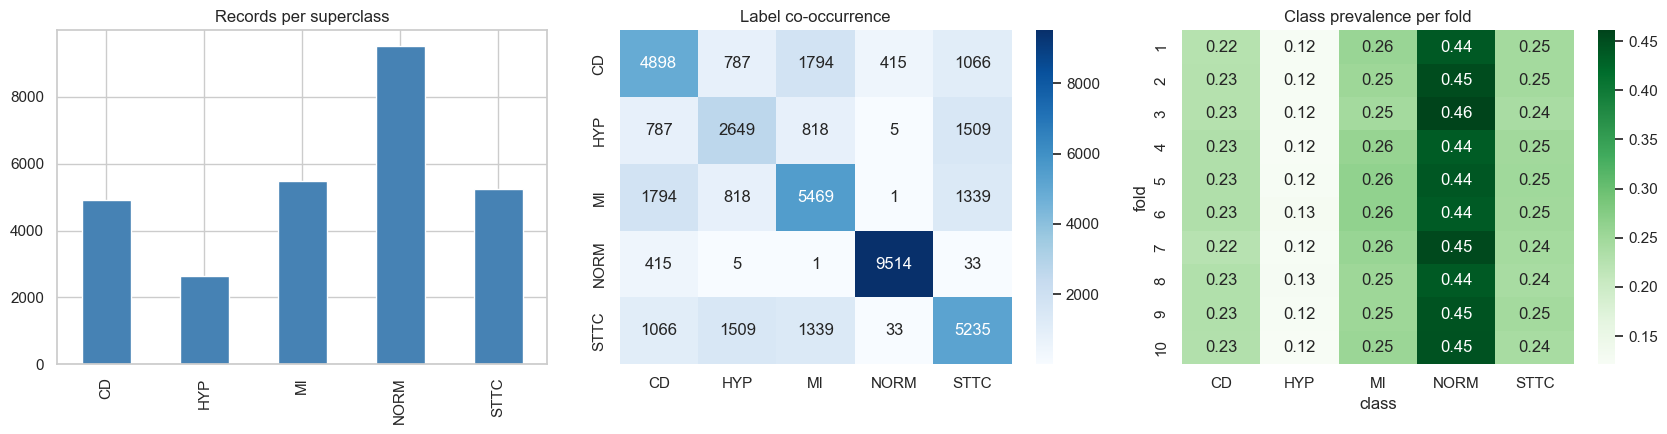

In [9]:
per_record = labels.sum(axis=1)
print("Labels per record:")
print(pd.Series(per_record).value_counts().sort_index().rename("records").to_string())

cooc = pd.DataFrame(labels.T @ labels, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
pd.Series(labels.sum(axis=0), index=CLASS_NAMES).plot.bar(ax=ax[0], color="steelblue")
ax[0].set_title("Records per superclass")
sns.heatmap(cooc, annot=True, fmt="d", cmap="Blues", ax=ax[1]); ax[1].set_title("Label co-occurrence")
fold_class = pd.DataFrame(labels, columns=CLASS_NAMES).groupby(clean_metadata["strat_fold"].values).mean()
sns.heatmap(fold_class, annot=True, fmt=".2f", cmap="Greens", ax=ax[2])
ax[2].set_title("Class prevalence per fold"); ax[2].set_xlabel("class"); ax[2].set_ylabel("fold")
plt.tight_layout(); save_fig("02_label_eda.png"); plt.show()

## 3. Waveforms and delineation

### 3.1 Loading, with the lead order verified

The extraction assumes the standard PTB-XL order `I, II, III, aVR, aVL, aVF, V1–V6`.
That assumption is checked against every record's WFDB header instead of being trusted.

In [10]:
def load_ecg(record):
    # record: dict / Series with key "filename_hr". Returns (n_samples, 12) signal in mV.
    signal, fields = wfdb.rdsamp(os.path.join(DATA_DIR, record["filename_hr"]))
    names = [s.lower() for s in fields["sig_name"]]
    if names != [n.lower() for n in LEAD_NAMES]:
        raise ValueError(f"unexpected lead order: {fields['sig_name']}")
    if signal.shape[1] != 12:
        raise ValueError(f"expected 12 leads, got {signal.shape[1]}")
    if not np.isfinite(signal).all():
        raise ValueError("signal contains NaN/inf samples")
    return signal


sample_rec = clean_metadata.iloc[0]
sample_signal = load_ecg(sample_rec)
print("ecg_id:", sample_rec["ecg_id"], "| shape:", sample_signal.shape,
      "| duration:", sample_signal.shape[0] / SAMPLING_RATE, "s")
print("Superclass:", sample_rec["diagnostic_superclass"])

ecg_id: 1 | shape: (5000, 12) | duration: 10.0 s
Superclass: ['NORM']


saved: ../outputs/v5_final\figures\03_example_12_lead.png


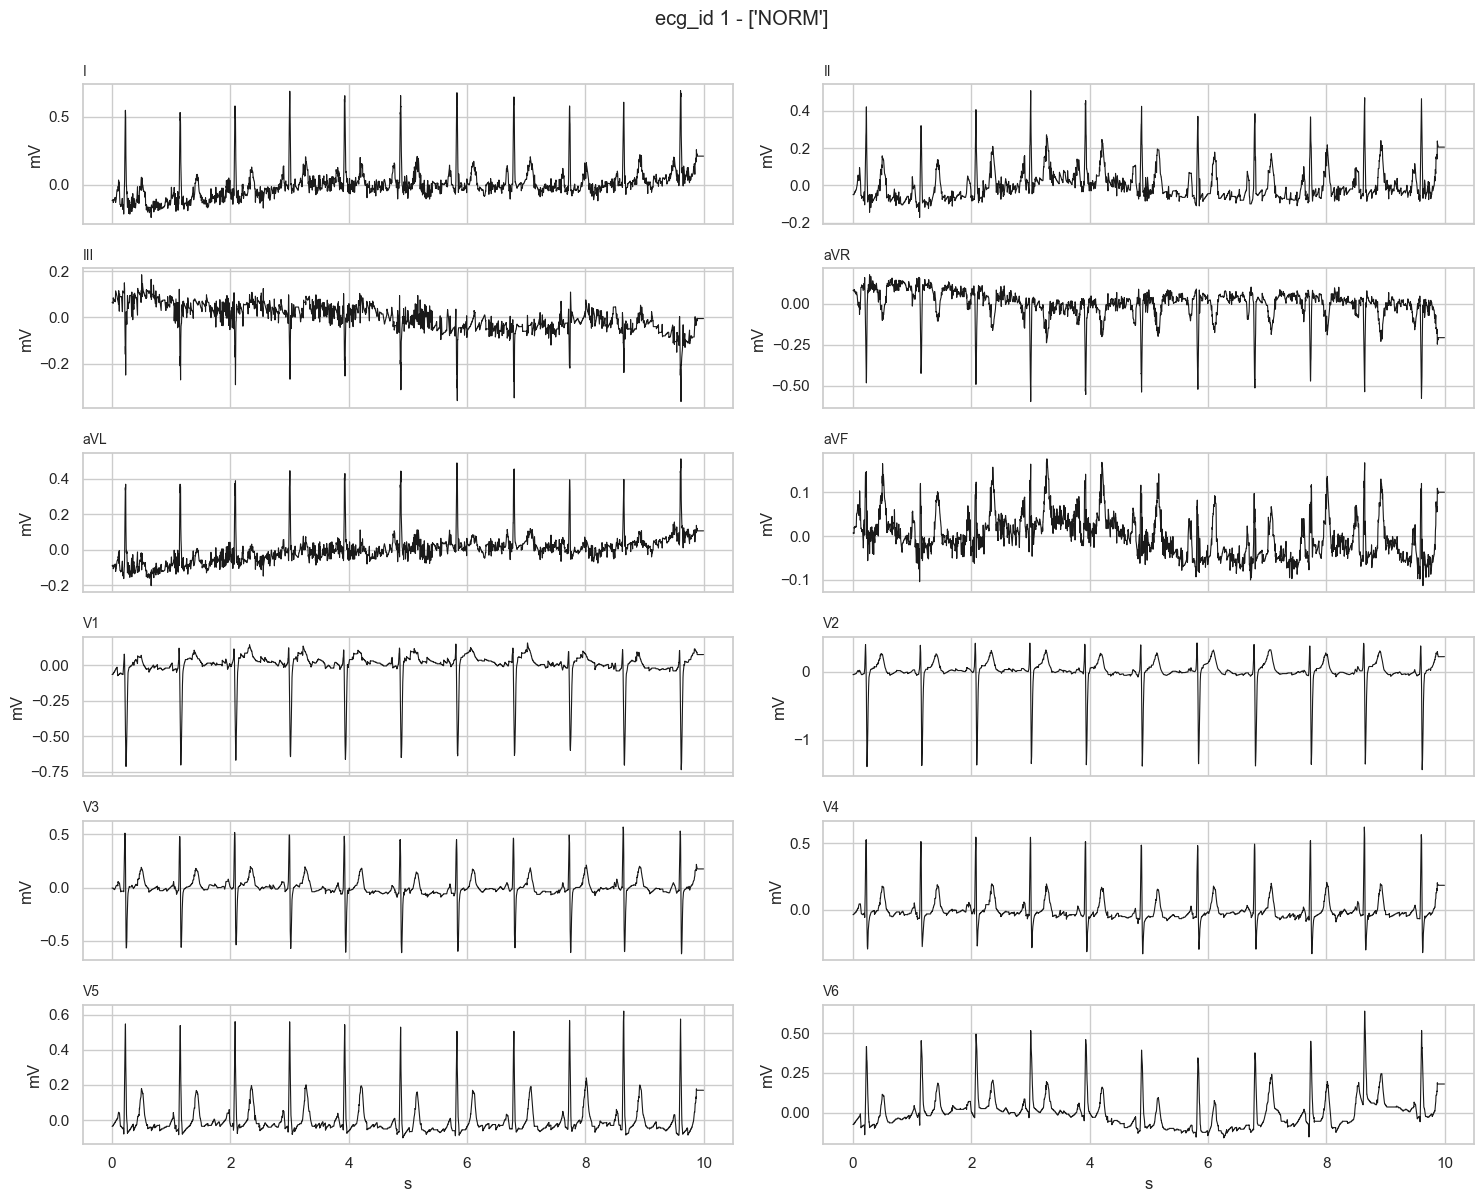

In [11]:
def plot_12_lead(signal, fs, title=""):
    t = np.arange(signal.shape[0]) / fs
    fig, axes = plt.subplots(6, 2, figsize=(15, 12), sharex=True)
    for i, ax in enumerate(axes.flatten()):
        ax.plot(t, signal[:, i], lw=0.8, color="k")
        ax.set_title(LEAD_NAMES[i], loc="left", fontsize=10)
        ax.set_ylabel("mV")
    axes[-1, 0].set_xlabel("s"); axes[-1, 1].set_xlabel("s")
    fig.suptitle(title, y=1.0)
    plt.tight_layout()

plot_12_lead(sample_signal, SAMPLING_RATE,
             f"ecg_id {sample_rec['ecg_id']} - {sample_rec['diagnostic_superclass']}")
save_fig("03_example_12_lead.png"); plt.show()

### 3.2 R-peak detection, delineation and the beat table

Detection and delineation (NeuroKit2, DWT method) run on lead II. If that fails (flat lead,
too few peaks), lead I and then V5 are tried. Because the 12 leads are recorded simultaneously,
fiducial sample indices found on one lead apply to all of them.

The **beat table** has one row per detected beat; every P/Q/S/T/QRS point is matched to *its own*
R peak inside a physiological search window, or left as NaN.

**QRS limits (v5).** The DWT QRS onset/offset of a single lead proved too wide, so the QRS onset and
offset are re-measured on the **12-lead spatial velocity** `sqrt(sum_leads (dV/dt)^2)`: the QRS starts/ends where it falls
below 12 % of its peak value and stays there for 10 ms. This is how the global QRS duration is read clinically
(earliest onset / latest offset over all leads). The DWT limits are only a per-beat fallback. (Filtering each wave array for NaN
independently and zipping by position pairs onsets and offsets from different beats.)

In [12]:
def detect_and_delineate(signal, fs):
    # Returns (cleaned_signal, r_peaks, waves, detection_lead)
    last_err = None
    for ln in DETECTION_LEADS:
        try:
            x = signal[:, LEAD_IDX[ln]]
            cleaned = nk.ecg_clean(x, sampling_rate=fs, method="neurokit")
            r = np.asarray(nk.ecg_peaks(cleaned, sampling_rate=fs)[1]["ECG_R_Peaks"], dtype=int)
            if len(r) < 3:
                raise ValueError(f"only {len(r)} R peaks on lead {ln}")
            _, waves = nk.ecg_delineate(cleaned, r, sampling_rate=fs, method="dwt")
            return cleaned, r, waves, ln
        except Exception as e:                      # try the next lead
            last_err = e
    raise ValueError(f"delineation failed on {DETECTION_LEADS}: {last_err!r}")


def _nearest(ref, candidates, lo, hi):
    # Candidate nearest to `ref` inside [ref+lo, ref+hi] (samples), else NaN.
    if candidates is None or len(candidates) == 0:
        return np.nan
    c = np.asarray(candidates, dtype=float)
    c = c[~np.isnan(c)]
    c = c[(c >= ref + lo) & (c <= ref + hi)]
    return float(c[np.argmin(np.abs(c - ref))]) if c.size else np.nan


# ---- QRS onset / offset from the 12-lead spatial velocity ---------------------------------
QRS_VEL_FRAC = 0.12     # QRS limits: velocity falls below this fraction of its QRS peak ...
QRS_HOLD_MS  = 10       # ... and stays there for this many ms


def spatial_velocity(signal, fs):
    # Zero-phase band-passed (0.5-40 Hz) 12-lead spatial velocity in mV/s.
    sos = butter(2, [0.5, 40.0], btype="bandpass", fs=fs, output="sos")
    x = sosfiltfilt(sos, signal, axis=0)
    v = np.sqrt(np.sum(np.diff(x, axis=0) ** 2, axis=1)) * fs
    v = np.concatenate([v[:1], v])
    k = max(1, int(round(0.008 * fs)))                       # 8 ms moving average
    return np.convolve(v, np.ones(k) / k, mode="same")


def refine_qrs_bounds(signal, r_peaks, fs, frac=QRS_VEL_FRAC, hold_ms=QRS_HOLD_MS):
    # Returns (onset, offset) sample indices per R peak; NaN where the limits cannot be established.
    v = spatial_velocity(signal, fs)
    n = len(v)
    ms = lambda t: int(round(t * fs / 1000.0))
    hold = max(2, ms(hold_ms))
    floor = 2.0 * float(np.median(v))                        # noise floor: median velocity is dominated by quiet segments
    on = np.full(len(r_peaks), np.nan)
    off = np.full(len(r_peaks), np.nan)
    for k, r in enumerate(np.asarray(r_peaks, dtype=float)):
        if np.isnan(r):
            continue
        r = int(r)
        lo, hi = r - ms(130), r + ms(150)
        if lo < 0 or hi >= n:
            continue
        c0 = r - ms(60)
        core = v[c0: r + ms(60) + 1]
        pk = c0 + int(np.argmax(core))
        vmax = float(v[pk])
        thr = max(frac * vmax, floor)
        if vmax <= 0 or thr >= 0.5 * vmax:                   # too noisy to separate the QRS from the baseline
            continue
        run = 0                                              # backwards from the velocity peak -> onset
        for i in range(pk, lo - 1, -1):
            run = run + 1 if v[i] < thr else 0
            if run >= hold:
                on[k] = i + run - 1
                break
        run = 0                                              # forwards from the velocity peak -> offset
        for i in range(pk, hi + 1):
            run = run + 1 if v[i] < thr else 0
            if run >= hold:
                off[k] = i - run + 1
                break
    return on, off


def build_beat_table(waves, r_peaks, fs, signal=None):
    ms = lambda x: int(round(x * fs / 1000.0))
    # search windows relative to the R peak, in milliseconds
    win = {"P_on": (-400, -70), "P": (-350, -60), "P_off": (-300, -40),
           "QRS_on": (-120, -5), "Q": (-100, -2), "QRS_off": (5, 140), "S": (2, 120),
           "T_on": (40, 400), "T": (80, 600), "T_off": (120, 700)}
    key = {"P_on": "ECG_P_Onsets", "P": "ECG_P_Peaks", "P_off": "ECG_P_Offsets",
           "QRS_on": "ECG_R_Onsets", "Q": "ECG_Q_Peaks", "QRS_off": "ECG_R_Offsets",
           "S": "ECG_S_Peaks", "T_on": "ECG_T_Onsets", "T": "ECG_T_Peaks", "T_off": "ECG_T_Offsets"}
    rows = []
    for r in np.asarray(r_peaks, dtype=float):
        row = {"R": r}
        for name, (lo_ms, hi_ms) in win.items():
            row[name] = _nearest(r, waves.get(key[name], []), ms(lo_ms), ms(hi_ms))
        rows.append(row)
    bt = pd.DataFrame(rows)
    rr_prev = np.full(len(bt), np.nan)               # preceding RR in seconds (for rate correction)
    if len(bt) > 1:
        rr_prev[1:] = np.diff(bt["R"].values) / fs
    bt["RR_prev"] = rr_prev

    # QRS limits from the spatial velocity (DWT limits stay only where the refinement fails)
    bt["QRS_refined"] = 0.0
    if signal is not None and len(bt):
        on_r, off_r = refine_qrs_bounds(signal, bt["R"].values, fs)
        good = ~np.isnan(on_r) & ~np.isnan(off_r) & (off_r > on_r)
        bt.loc[good, "QRS_on"] = on_r[good]
        bt.loc[good, "QRS_off"] = off_r[good]
        bt.loc[good, "QRS_refined"] = 1.0
    return bt

saved: ../outputs/v5_final\figures\04_delineation_check.png


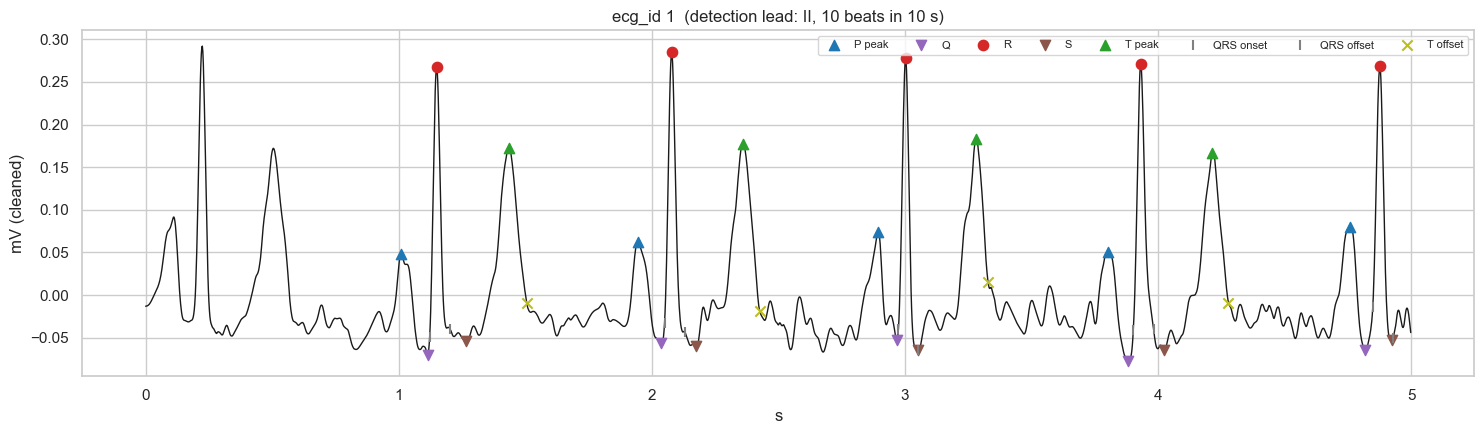

In [13]:
def plot_delineation(signal, fs, seconds=5, title=""):
    cleaned, r, waves, det = detect_and_delineate(signal, fs)
    bt = build_beat_table(waves, r, fs, signal)
    n = int(seconds * fs); t = np.arange(n) / fs
    plt.figure(figsize=(15, 4.5))
    plt.plot(t, cleaned[:n], lw=1, color="k")
    style = {"P": ("P peak", "tab:blue", "^"), "Q": ("Q", "tab:purple", "v"),
             "R": ("R", "tab:red", "o"), "S": ("S", "tab:brown", "v"),
             "T": ("T peak", "tab:green", "^"), "QRS_on": ("QRS onset", "gray", "|"),
             "QRS_off": ("QRS offset", "gray", "|"), "T_off": ("T offset", "tab:olive", "x")}
    for col, (lab, colr, mk) in style.items():
        idx = bt[col].dropna().astype(int).values
        idx = idx[idx < n]
        plt.scatter(idx / fs, cleaned[idx], c=colr, marker=mk, s=55, label=lab, zorder=3)
    plt.title(f"{title}  (detection lead: {det}, {len(r)} beats in 10 s)")
    plt.xlabel("s"); plt.ylabel("mV (cleaned)"); plt.legend(ncol=8, fontsize=8, loc="upper right")
    plt.tight_layout()

plot_delineation(sample_signal, SAMPLING_RATE, title=f"ecg_id {sample_rec['ecg_id']}")
save_fig("04_delineation_check.png"); plt.show()

saved: ../outputs/v5_final\figures\05_example_per_class.png


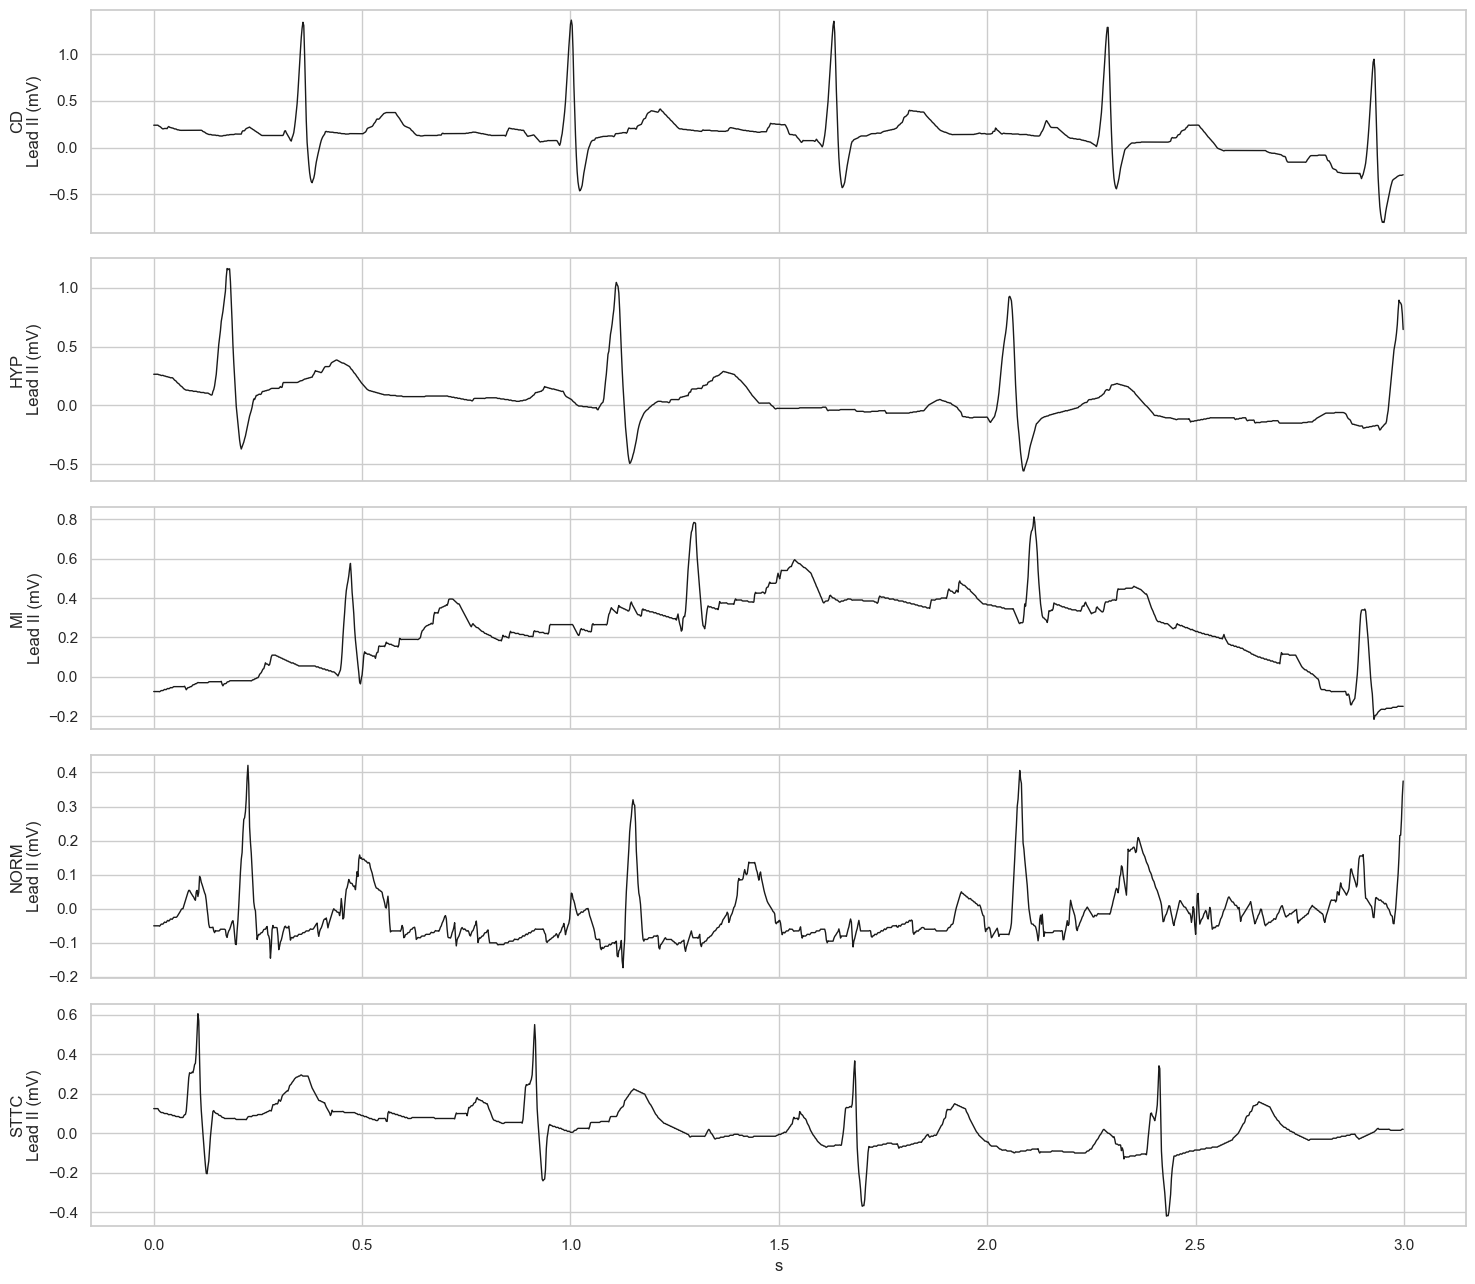

In [14]:
# One clean single-label example per class: eyeball that the fiducials are sensible everywhere.
single = clean_metadata[clean_metadata["diagnostic_superclass"].map(len) == 1]
fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(15, 2.6 * len(CLASS_NAMES)), sharex=True)
for ax, c in zip(axes, CLASS_NAMES):
    rec = single[single["diagnostic_superclass"].map(lambda x: x[0] == c)].iloc[0]
    sig = load_ecg(rec)
    ax.plot(np.arange(3 * SAMPLING_RATE) / SAMPLING_RATE, sig[:3 * SAMPLING_RATE, LEAD_IDX["II"]], lw=1, color="k")
    ax.set_ylabel(f"{c}\nLead II (mV)")
axes[-1].set_xlabel("s")
plt.tight_layout(); save_fig("05_example_per_class.png"); plt.show()

## 4. Feature extraction

Feature names carry a block prefix, so the ablation study can add and remove whole blocks
without a hand-maintained list.

| Prefix | Block | Content |
|---|---|---|
| `rhythm_` | Rhythm | Heart rate and time-domain HRV only (measures that are defined on a 10 s strip) |
| `intv_`   | Global intervals | PR, QRS, QT, QTc (Bazett, Fridericia), ST, JT — onset/offset based, per beat; QRS limits from the 12-lead spatial velocity |
| `clin_`   | Per-lead clinical | R/S/Q, J-point, ST60/ST80, T amplitude, QRS area, Q/R ratio per lead; Sokolow-Lyon, Cornell, Lewis, R-progression, QRS axis, regional ST summaries, Gubner, RVH index, Peguero-Lo Presti |
| `pwave_`  | P wave | P duration, P amplitude in II and V1, terminal P force in V1 (atrial enlargement belongs to the HYP superclass) |
| `morph_`  | Lead II morphology | Wave amplitudes, energy, Hjorth parameters |
| `beat_`   | Lead II beat shape | QRS/T width, slopes, area |
| `freq_`   | Lead II spectrum | FFT / Welch descriptors |
| `lead_`   | Per-lead statistics | mean, std, median, max, min, RMS, peak-to-peak |
| `demo_`   | Age, sex | Not an ECG feature; used only if `USE_DEMOGRAPHICS = True` or in the ablation |

Why the HRV block is small: on a 10 s strip there are ~10 RR intervals. Frequency-domain HRV is
undefined, and non-linear measures such as sample entropy are unstable, so they are not used.

In [15]:
# ---------- NaN-safe scalar helpers ----------
def _clean(a):
    a = np.asarray(a, dtype=float).ravel()
    return a[~np.isnan(a)]

def nmax(a):  a = _clean(a); return float(np.max(a))    if a.size else np.nan
def nmin(a):  a = _clean(a); return float(np.min(a))    if a.size else np.nan
def nmean(a): a = _clean(a); return float(np.mean(a))   if a.size else np.nan
def nmed(a):  a = _clean(a); return float(np.median(a)) if a.size else np.nan
def nstd(a):  a = _clean(a); return float(np.std(a))    if a.size > 1 else np.nan


# ---------- 4.1 Rhythm (time-domain HRV) ----------
RHYTHM_KEYS = ["heart_rate", "mean_rr", "median_rr", "min_rr", "max_rr", "sdnn", "rmssd",
               "pnn50", "cvnn", "rr_range", "rr_iqr", "rr_skew"]

def extract_rhythm_features(r_peaks, fs):
    f = {f"rhythm_{k}": np.nan for k in RHYTHM_KEYS}
    f["rhythm_n_beats"] = float(len(r_peaks))
    if len(r_peaks) < 3:
        return f
    rr_all = np.diff(np.asarray(r_peaks, dtype=float)) / fs
    ok = (rr_all > 0.25) & (rr_all < 3.0)                 # physiological RR only
    rr = rr_all[ok]
    if rr.size < 2:
        return f
    drr = np.diff(rr_all)[ok[:-1] & ok[1:]]               # successive differences of ADJACENT valid RRs
    m, s = np.mean(rr), np.std(rr)
    f["rhythm_heart_rate"] = 60.0 / m
    f["rhythm_mean_rr"]    = m
    f["rhythm_median_rr"]  = float(np.median(rr))
    f["rhythm_min_rr"]     = float(np.min(rr))
    f["rhythm_max_rr"]     = float(np.max(rr))
    f["rhythm_sdnn"]       = float(np.std(rr, ddof=1))
    f["rhythm_rmssd"]      = float(np.sqrt(np.mean(drr ** 2))) if drr.size else np.nan
    f["rhythm_pnn50"]      = float(100.0 * np.mean(np.abs(drr) > 0.05)) if drr.size else np.nan
    f["rhythm_cvnn"]       = f["rhythm_sdnn"] / m
    f["rhythm_rr_range"]   = float(np.ptp(rr))
    f["rhythm_rr_iqr"]     = float(np.percentile(rr, 75) - np.percentile(rr, 25))
    f["rhythm_rr_skew"]    = float(np.mean(((rr - m) / s) ** 3)) if s > 0 else np.nan
    return f


# ---------- 4.2 Global intervals ----------
RANGE = {"pr": (60, 400), "qrs": (40, 250), "qt": (200, 700),
         "st": (0, 300), "pr_seg": (0, 250), "jt": (100, 600)}     # accepted values, ms

def _gate(vals, key):
    lo, hi = RANGE[key]
    v = _clean(vals)
    return v[(v >= lo) & (v <= hi)]

def extract_interval_features(bt, fs):
    to_ms  = lambda d: d / fs * 1000.0
    pr     = _gate(to_ms(bt["QRS_on"] - bt["P_on"]).values,  "pr")
    pr_seg = _gate(to_ms(bt["QRS_on"] - bt["P_off"]).values, "pr_seg")
    qrs    = _gate(to_ms(bt["QRS_off"] - bt["QRS_on"]).values, "qrs")
    qt_raw = to_ms(bt["T_off"] - bt["QRS_on"]).values
    qt     = _gate(qt_raw, "qt")
    st     = _gate(to_ms(bt["T_on"] - bt["QRS_off"]).values, "st")
    jt     = _gate(to_ms(bt["T_off"] - bt["QRS_off"]).values, "jt")

    # rate correction beat by beat, using the PRECEDING RR
    rr_prev = bt["RR_prev"].values
    ok = (~np.isnan(qt_raw)) & (~np.isnan(rr_prev)) & (rr_prev > 0.25) & (rr_prev < 3.0)
    ok &= (qt_raw >= RANGE["qt"][0]) & (qt_raw <= RANGE["qt"][1])
    qtc_b = qt_raw[ok] / np.sqrt(rr_prev[ok])       # Bazett
    qtc_f = qt_raw[ok] / np.cbrt(rr_prev[ok])       # Fridericia

    mean_rr_ms = nmean(rr_prev) * 1000.0
    return {
        "intv_pr": nmed(pr), "intv_pr_segment": nmed(pr_seg),
        "intv_qrs": nmed(qrs), "intv_qrs_sd": nstd(qrs),
        "intv_qt": nmed(qt), "intv_qtc_bazett": nmed(qtc_b), "intv_qtc_frid": nmed(qtc_f),
        "intv_st_segment": nmed(st), "intv_jt": nmed(jt),
        "intv_qt_rr_ratio": nmed(qt) / mean_rr_ms if mean_rr_ms and not np.isnan(mean_rr_ms) else np.nan,
        "intv_n_valid_qrs": float(len(qrs)), "intv_n_valid_qt": float(len(qt)),
        "intv_p_detect_frac": float(bt["P"].notna().mean()),
        "intv_t_detect_frac": float(bt["T"].notna().mean()),
        "intv_qrs_refined_frac": float(bt["QRS_refined"].mean()) if "QRS_refined" in bt else np.nan,
    }

In [16]:
# ---------- 4.3 Per-lead clinical measurements and criteria ----------
ANTERIOR = ["V1", "V2", "V3", "V4"]
INFERIOR = ["II", "III", "aVF"]
LATERAL  = ["I", "aVL", "V5", "V6"]
PRECORD  = ["V1", "V2", "V3", "V4", "V5", "V6"]

def extract_clinical_lead_features(signal, bt, fs):
    # Every lead is measured against its OWN isoelectric baseline (PR segment; 40 ms pre-QRS as fallback).
    # Sign convention: R >= 0, S <= 0, Q <= 0 (0 means "no such wave"). Units: mV, mV*ms.
    f, n_s = {}, signal.shape[0]
    off60, off80, pre40 = int(round(0.060 * fs)), int(round(0.080 * fs)), int(round(0.040 * fs))

    valid = bt.dropna(subset=["QRS_on", "QRS_off"])
    beats = []
    for b in valid.itertuples(index=False):
        p_off = int(b.P_off) if not np.isnan(b.P_off) else -1
        t_pk  = int(b.T)     if not np.isnan(b.T)     else -1
        beats.append((int(b.QRS_on), int(b.QRS_off), int(b.R), p_off, t_pk))

    per_lead = {}
    for name, li in LEAD_IDX.items():
        lead = signal[:, li]
        R_, S_, Q_, J_, ST60_, ST80_, T_, AREA_ = ([] for _ in range(8))
        for on, off, r, p_off, t_pk in beats:
            if not (0 <= on < off < n_s):
                continue
            if 0 <= p_off < on:
                base = float(np.median(lead[p_off:on]))
            else:
                lo = max(0, on - pre40)
                base = float(np.median(lead[lo:on])) if on > lo else 0.0
            seg = lead[on:off] - base
            if seg.size == 0:
                continue
            k = int(np.clip(r - on, 0, seg.size - 1))            # R position inside the QRS segment
            R_.append(max(float(np.max(seg)), 0.0))
            S_.append(min(float(np.min(seg[k:])), 0.0))
            Q_.append(min(float(np.min(seg[:max(k, 1)])), 0.0))
            AREA_.append(float(trapezoid(seg) / fs * 1000.0))
            J_.append(float(lead[off] - base))
            if off + off60 < n_s: ST60_.append(float(lead[off + off60] - base))
            if off + off80 < n_s: ST80_.append(float(lead[off + off80] - base))
            if 0 <= t_pk < n_s:   T_.append(float(lead[t_pk] - base))

        m = {"R": nmed(R_), "S": nmed(S_), "Q": nmed(Q_), "J": nmed(J_), "ST60": nmed(ST60_),
             "ST80": nmed(ST80_), "T": nmed(T_), "AREA": nmed(AREA_)}
        per_lead[name] = m
        for k_, v_ in [("R", m["R"]), ("S", m["S"]), ("Q", m["Q"]), ("J", m["J"]), ("ST60", m["ST60"]),
                       ("ST80", m["ST80"]), ("T", m["T"]), ("area", m["AREA"])]:
            f[f"clin_{name}_{k_}"] = v_
        # pathological-Q indicator: Q depth relative to R height (denominators floored -> no blow-ups)
        f[f"clin_{name}_QR_ratio"] = abs(m["Q"]) / m["R"] if (not np.isnan(m["R"]) and m["R"] > 0.05
                                                              and not np.isnan(m["Q"])) else np.nan
        f[f"clin_{name}_RS_ratio"] = m["R"] / max(abs(m["S"]), 0.02) if not (np.isnan(m["R"]) or np.isnan(m["S"])) else np.nan

    g = lambda ld, k: per_lead[ld][k]

    # ---- hypertrophy voltage criteria ----
    f["clin_sokolow_lyon"]     = abs(g("V1", "S")) + np.fmax(g("V5", "R"), g("V6", "R"))
    f["clin_cornell_volt"]     = g("aVL", "R") + abs(g("V3", "S"))
    f["clin_cornell_prod"]     = np.nan                       # completed in extract_complete_features (needs QRS)
    f["clin_lewis_index"]      = (g("I", "R") - g("III", "R")) + (abs(g("III", "S")) - abs(g("I", "S")))
    f["clin_RV5_SV1"]          = g("V5", "R") + abs(g("V1", "S"))
    f["clin_gubner"]           = g("I", "R") + abs(g("III", "S"))                                 # Gubner-Ungerleider
    f["clin_rvh_index"]        = g("V1", "R") + abs(g("V5", "S"))                                 # R V1 + S V5 (right ventricle)
    f["clin_peguero"]          = abs(nmin([g(l, "S") for l in PRECORD])) + abs(g("V4", "S"))       # Peguero-Lo Presti
    f["clin_RV6_RV5_ratio"]    = g("V6", "R") / g("V5", "R") if g("V5", "R") and g("V5", "R") > 0.05 else np.nan
    f["clin_max_R_precordial"] = nmax([g(l, "R") for l in PRECORD])
    f["clin_max_S_precordial"] = nmin([g(l, "S") for l in PRECORD])

    # ---- R-wave progression ----
    rs = np.array([g(l, "R") for l in PRECORD], dtype=float)
    ss = np.array([abs(g(l, "S")) for l in PRECORD], dtype=float)
    good = ~np.isnan(rs)
    f["clin_r_progression_slope"] = float(np.polyfit(np.arange(6)[good], rs[good], 1)[0]) if good.sum() >= 3 else np.nan
    both = ~np.isnan(rs) & ~np.isnan(ss)
    if both.sum() >= 4:
        trans = np.where(rs[both] > ss[both])[0]
        f["clin_transition_lead"] = float(np.arange(1, 7)[both][trans[0]]) if trans.size else 7.0   # 7 = never
    else:
        f["clin_transition_lead"] = np.nan

    # ---- frontal-plane QRS axis from NET QRS AREA in leads I and aVF ----
    net_I, net_F = g("I", "AREA"), g("aVF", "AREA")
    if np.isnan(net_I) or np.isnan(net_F):
        ang = np.nan
    else:
        ang = float(np.degrees(np.arctan2(net_F, net_I)))
    f["clin_qrs_axis"]     = ang
    f["clin_qrs_axis_sin"] = float(np.sin(np.radians(ang))) if not np.isnan(ang) else np.nan
    f["clin_qrs_axis_cos"] = float(np.cos(np.radians(ang))) if not np.isnan(ang) else np.nan
    f["clin_net_area_I"], f["clin_net_area_aVF"] = net_I, net_F

    # ---- regional ST / T summaries ----
    for region, leads in [("ant", ANTERIOR), ("inf", INFERIOR), ("lat", LATERAL)]:
        st = [g(l, "ST60") for l in leads]; tw = [g(l, "T") for l in leads]
        f[f"clin_st60_{region}_mean"] = nmean(st)
        f[f"clin_st60_{region}_max"]  = nmax(st)
        f[f"clin_st60_{region}_min"]  = nmin(st)
        f[f"clin_t_{region}_mean"]    = nmean(tw)

    all_st = np.array([g(l, "ST60") for l in LEAD_NAMES], dtype=float)
    all_t  = np.array([g(l, "T")    for l in LEAD_NAMES], dtype=float)
    q_leads = [l for l in LEAD_NAMES if l not in ("aVR", "V1")]        # Q waves in aVR / V1 are normal
    all_qr = np.array([f[f"clin_{l}_QR_ratio"] for l in q_leads], dtype=float)
    cnt = lambda arr, cond: float(np.sum(cond)) if np.any(~np.isnan(arr)) else np.nan
    f["clin_st_max_elev"]     = nmax(all_st)
    f["clin_st_max_depr"]     = nmin(all_st)
    f["clin_n_leads_st_up"]   = cnt(all_st, all_st > 0.1)       # >= 1 mm
    f["clin_n_leads_st_down"] = cnt(all_st, all_st < -0.1)
    f["clin_n_leads_t_inv"]   = cnt(all_t,  all_t < -0.1)
    f["clin_n_leads_path_q"]  = cnt(all_qr, all_qr > 0.25)      # Q deeper than 25 % of R
    f["clin_max_qr_ratio"]    = nmax(all_qr)
    return f


# ---------- 4.3b P-wave features (atrial enlargement is part of the HYP superclass) ----------
PWAVE_KEYS = ["pwave_dur", "pwave_dur_sd", "pwave_II_pos", "pwave_II_neg", "pwave_V1_pos",
              "pwave_V1_neg", "pwave_V1_ptf", "pwave_n_valid"]


def extract_pwave_features(signal, bt, fs):
    # P wave measured against the PR-segment baseline; only beats with a plausible P (40-200 ms) are used.
    f = {k: np.nan for k in PWAVE_KEYS}
    n = signal.shape[0]
    pre40 = int(round(0.040 * fs))
    pos, neg, ptf, durs = {"II": [], "V1": []}, {"II": [], "V1": []}, [], []
    for b in bt[["P_on", "P_off", "QRS_on"]].dropna().itertuples(index=False):
        p_on, p_off, q_on = int(b.P_on), int(b.P_off), int(b.QRS_on)
        d = (p_off - p_on) / fs * 1000.0
        if not (0 <= p_on < p_off < q_on < n) or not (40.0 <= d <= 200.0):
            continue
        durs.append(d)
        for ln in ("II", "V1"):
            x = signal[:, LEAD_IDX[ln]]
            base = float(np.median(x[p_off:q_on])) if q_on - p_off >= 2 else float(np.median(x[max(0, q_on - pre40):q_on]))
            seg = x[p_on:p_off + 1] - base
            pos[ln].append(max(float(seg.max()), 0.0))
            neg[ln].append(min(float(seg.min()), 0.0))
            if ln == "V1":
                half = seg[len(seg) // 2:]                                  # terminal half of the P wave
                depth = min(float(half.min()), 0.0)
                width = float(np.sum(half < 0)) / fs * 1000.0
                ptf.append(abs(depth) * width)                              # mV*ms, terminal force of P in V1
    f["pwave_n_valid"] = float(len(durs))
    if durs:
        f["pwave_dur"], f["pwave_dur_sd"] = float(np.median(durs)), nstd(durs)
        f["pwave_II_pos"], f["pwave_II_neg"] = nmed(pos["II"]), nmed(neg["II"])
        f["pwave_V1_pos"], f["pwave_V1_neg"] = nmed(pos["V1"]), nmed(neg["V1"])
        f["pwave_V1_ptf"] = nmed(ptf)
    return f


In [17]:
# ---------- 4.4 Lead II morphology / beat shape / spectrum / per-lead statistics ----------
from scipy.fft import rfft, rfftfreq
from scipy.signal import welch
from scipy.stats import entropy

def extract_morphology_features(signal, bt):
    lead = signal[:, LEAD_IDX["II"]]; n = len(lead); f = {}

    def amps(col):
        idx = bt[col].dropna().values.astype(int)
        idx = idx[(idx >= 0) & (idx < n)]
        return lead[idx] if idx.size else np.array([])

    for wave, col in [("p", "P"), ("q", "Q"), ("r", "R"), ("s", "S"), ("t", "T")]:
        v = amps(col)
        f[f"morph_{wave}_amp_mean"] = float(np.mean(v)) if v.size else np.nan
        f[f"morph_{wave}_amp_std"]  = float(np.std(v))  if v.size else np.nan
        f[f"morph_{wave}_amp_max"]  = float(np.max(v))  if v.size else np.nan
        f[f"morph_{wave}_amp_min"]  = float(np.min(v))  if v.size else np.nan

    r_, s_, q_ = f["morph_r_amp_mean"], abs(f["morph_s_amp_mean"]), abs(f["morph_q_amp_mean"])
    f["morph_r_s_ratio"] = r_ / max(s_, 0.02) if not np.isnan(r_) and not np.isnan(s_) else np.nan
    f["morph_r_q_ratio"] = r_ / max(q_, 0.02) if not np.isnan(r_) and not np.isnan(q_) else np.nan

    d   = np.diff(lead)
    rms = float(np.sqrt(np.mean(lead ** 2)))
    var = float(np.var(lead))
    f["morph_peak_to_peak"]       = float(np.ptp(lead))
    f["morph_signal_energy"]      = float(np.sum(lead ** 2))
    f["morph_signal_rms"]         = rms
    f["morph_mean_abs_amplitude"] = float(np.mean(np.abs(lead)))
    f["morph_crest_factor"]       = float(np.max(np.abs(lead)) / rms) if rms > 0 else np.nan
    f["morph_waveform_length"]    = float(np.sum(np.abs(d)))
    f["morph_hjorth_activity"]    = var
    f["morph_hjorth_mobility"]    = float(np.sqrt(np.var(d) / var)) if var > 0 else np.nan
    return f


def extract_beat_morphology_features(signal, bt, fs):
    lead = signal[:, LEAD_IDX["II"]]; f = {}
    to_ms = lambda d: d / fs * 1000.0

    qw = _clean(to_ms((bt["QRS_off"] - bt["QRS_on"]).values)); qw = qw[(qw >= 40) & (qw <= 250)]
    tw = _clean(to_ms((bt["T_off"] - bt["T_on"]).values));     tw = tw[(tw >= 50) & (tw <= 400)]
    f["beat_qrs_width_mean"] = float(np.mean(qw)) if qw.size else np.nan
    f["beat_qrs_width_std"]  = float(np.std(qw))  if qw.size > 1 else np.nan
    f["beat_t_width_mean"]   = float(np.mean(tw)) if tw.size else np.nan
    f["beat_t_width_std"]    = float(np.std(tw))  if tw.size > 1 else np.nan

    up, down, area = [], [], []
    for b in bt.itertuples(index=False):
        r = int(b.R)
        if not np.isnan(b.Q):
            q = int(b.Q);  up.append((lead[r] - lead[q]) / max(r - q, 1))
        if not np.isnan(b.S):
            s = int(b.S);  down.append((lead[r] - lead[s]) / max(s - r, 1))
        if not (np.isnan(b.QRS_on) or np.isnan(b.QRS_off)):
            on, off = int(b.QRS_on), int(b.QRS_off)
            if 0 <= on < off <= len(lead):
                area.append(float(np.sum(np.abs(lead[on:off]))))
    for name, vals in [("upstroke", up), ("downstroke", down), ("area", area)]:
        f[f"beat_{name}_mean"] = float(np.mean(vals)) if vals else np.nan
        f[f"beat_{name}_std"]  = float(np.std(vals))  if len(vals) > 1 else np.nan
    return f


def extract_frequency_features(signal, fs):
    lead = signal[:, LEAD_IDX["II"]]
    fft_v = np.abs(rfft(lead))[1:]                       # drop DC
    freqs = rfftfreq(len(lead), d=1.0 / fs)[1:]
    tot = float(np.sum(fft_v))
    centroid  = float(np.sum(freqs * fft_v) / tot) if tot else np.nan
    bandwidth = float(np.sqrt(np.sum(((freqs - centroid) ** 2) * fft_v) / tot)) if tot else np.nan
    p = fft_v ** 2
    p = p / np.sum(p) if np.sum(p) else p
    fr, psd = welch(lead, fs=fs, nperseg=min(1024, len(lead)))
    return {"freq_dominant": float(freqs[int(np.argmax(fft_v))]), "freq_centroid": centroid,
            "freq_bandwidth": bandwidth, "freq_entropy": float(entropy(p)) if np.sum(p) else np.nan,
            "freq_total_power": float(trapezoid(psd, fr))}


def extract_per_lead_features(signal):
    f = {}
    for name, i in LEAD_IDX.items():
        x = signal[:, i]
        f[f"lead_{name}_mean"]   = float(np.mean(x))
        f[f"lead_{name}_std"]    = float(np.std(x))
        f[f"lead_{name}_median"] = float(np.median(x))
        f[f"lead_{name}_max"]    = float(np.max(x))
        f[f"lead_{name}_min"]    = float(np.min(x))
        f[f"lead_{name}_rms"]    = float(np.sqrt(np.mean(x ** 2)))
        f[f"lead_{name}_ptp"]    = float(np.ptp(x))
    return f


# ---------- 4.5 Complete per-record extractor ----------
def extract_complete_features(signal, fs=SAMPLING_RATE):
    # Returns (feature_dict, detection_lead)
    cleaned, r_peaks, waves, det_lead = detect_and_delineate(signal, fs)
    bt = build_beat_table(waves, r_peaks, fs, signal)

    f = {}
    f.update(extract_rhythm_features(r_peaks, fs))
    f.update(extract_interval_features(bt, fs))
    f.update(extract_clinical_lead_features(signal, bt, fs))
    f.update(extract_pwave_features(signal, bt, fs))
    f.update(extract_morphology_features(signal, bt))
    f.update(extract_beat_morphology_features(signal, bt, fs))
    f.update(extract_frequency_features(signal, fs))
    f.update(extract_per_lead_features(signal))

    # Cornell product = Cornell voltage x QRS duration (mV*ms)
    cv, qd = f.get("clin_cornell_volt", np.nan), f.get("intv_qrs", np.nan)
    f["clin_cornell_prod"] = cv * qd if not (np.isnan(cv) or np.isnan(qd)) else np.nan
    return f, det_lead

### 4.6 Sanity check on one record

Before the full run, the measured values are compared with normal-ECG ranges. If these look
wrong, stop and fix the extractor — do not launch a one-hour extraction on broken features.

In [18]:
_feat, _lead = extract_complete_features(sample_signal)
print("Total features:", len(_feat), "| detection lead:", _lead)

NORMAL = {  # feature: (low, high, unit) — typical adult normal ECG
    "rhythm_heart_rate": (50, 100, "bpm"), "intv_pr": (120, 200, "ms"), "intv_qrs": (70, 110, "ms"),
    "intv_qt": (330, 460, "ms"), "intv_qtc_bazett": (350, 460, "ms"), "intv_qtc_frid": (350, 460, "ms"),
    "clin_sokolow_lyon": (0.0, 3.5, "mV"), "clin_qrs_axis": (-30, 90, "deg"),
}
print(f"\n{'feature':22s} {'value':>10s}   normal range")
for k, (lo, hi, u) in NORMAL.items():
    v = _feat.get(k, np.nan)
    flag = "" if (not np.isnan(v) and lo <= v <= hi) else "   <-- outside typical range (may be legitimate for this patient)"
    print(f"{k:22s} {v:10.2f}   {lo}-{hi} {u}{flag}")
print("\nQRS limits taken from the spatial velocity in %.0f %% of the beats of this record" % (100 * _feat["intv_qrs_refined_frac"]))


Total features: 322 | detection lead: II

feature                     value   normal range
rhythm_heart_rate           63.84   50-100 bpm
intv_pr                    145.00   120-200 ms
intv_qrs                    80.00   70-110 ms
intv_qt                    376.00   330-460 ms
intv_qtc_bazett            384.48   350-460 ms
intv_qtc_frid              379.25   350-460 ms
clin_sokolow_lyon            1.26   0.0-3.5 mV
clin_qrs_axis               15.49   -30-90 deg

QRS limits taken from the spatial velocity in 100 % of the beats of this record


## 5. Run extraction over the whole cohort

* Records are processed in **parallel** (`N_JOBS` workers) and in **chunks of `CHUNK_SIZE`**;
  each finished chunk is written to `CACHE_DIR`, so an interrupted run resumes where it stopped.
* Every result carries its `ecg_id`; on reload the id is checked against `clean_metadata`, so features
  can never be silently mis-aligned with labels.
* Failures are stored in **one** list and reported honestly (with the reason).

In [19]:
def _extract_one(i, rec):
    warnings.filterwarnings("ignore")
    try:
        sig = load_ecg(rec)
        f, lead = extract_complete_features(sig, SAMPLING_RATE)
        f["_det_lead"] = lead
        return i, rec["ecg_id"], f, None
    except Exception as e:
        return i, rec["ecg_id"], None, repr(e)[:200]


def run_extraction(df):
    n = len(df)
    spans = [(s, min(s + CHUNK_SIZE, n)) for s in range(0, n, CHUNK_SIZE)]
    todo = [(s, e) for s, e in spans
            if FORCE_EXTRACT or not os.path.exists(os.path.join(CACHE_DIR, f"chunk_{s:06d}_{e:06d}.pkl"))]
    print(f"{len(spans)} chunks total | {len(spans) - len(todo)} cached | {len(todo)} to compute | {N_JOBS} workers")
    t0 = time.time()
    for s, e in tqdm(todo, desc="Extracting chunks"):
        recs = df.iloc[s:e][["ecg_id", "filename_hr"]].to_dict("records")
        out = Parallel(n_jobs=N_JOBS)(delayed(_extract_one)(s + k, r) for k, r in enumerate(recs))
        joblib.dump(out, os.path.join(CACHE_DIR, f"chunk_{s:06d}_{e:06d}.pkl"))
    if todo:
        print(f"Extraction time: {(time.time() - t0) / 60:.1f} min")
    results = []
    for s, e in spans:
        results.extend(joblib.load(os.path.join(CACHE_DIR, f"chunk_{s:06d}_{e:06d}.pkl")))
    return results


results = run_extraction(clean_metadata)
assert len(results) == len(clean_metadata)
for i, eid, _, _ in results:                                     # alignment guard
    assert clean_metadata.iloc[i]["ecg_id"] == eid, "cache is misaligned with metadata - set FORCE_EXTRACT=True"
print("Cache aligned with metadata.")

22 chunks total | 0 cached | 22 to compute | 13 workers


Extracting chunks:   0%|          | 0/22 [00:00<?, ?it/s]

Extraction time: 4.3 min
Cache aligned with metadata.


In [20]:
ok  = [(i, eid, f) for i, eid, f, err in results if f is not None]
bad = [(i, eid, err) for i, eid, f, err in results if f is None]

failures = pd.DataFrame(bad, columns=["row", "ecg_id", "error"])
failures.to_csv(os.path.join(TABLE_DIR, "extraction_failures.csv"), index=False)
print(f"Succeeded : {len(ok)}")
print(f"Failed    : {len(failures)}  ({100 * len(failures) / len(results):.2f} %)")
if len(failures):
    print("\nFailure reasons:")
    print(failures["error"].str.replace(r"\d+", "N", regex=True).str[:80].value_counts().head(8).to_string())
    fail_cls = pd.Series(labels[failures["row"].values].sum(0), index=CLASS_NAMES) / labels.sum(0)
    print("\nFraction of each class lost to failures (should be small and even):")
    print((100 * fail_cls).round(2).to_string())

idx        = [i for i, _, _ in ok]
det_leads  = [f.pop("_det_lead") for _, _, f in ok]
feat       = pd.DataFrame([f for _, _, f in ok])
meta_ok    = clean_metadata.iloc[idx].reset_index(drop=True)
print("\nDetection lead used:", pd.Series(det_leads).value_counts().to_dict())

# --- assemble matrices (ids, folds, patients, labels all come from the SAME rows) ---
X_full = feat.copy()
X_full["demo_age"] = meta_ok["age"].values
X_full["demo_sex"] = meta_ok["sex"].values.astype(float)
Y_all    = labels[idx].astype(int)
folds    = meta_ok["strat_fold"].values
patients = meta_ok["patient_id"].values
ecg_ids  = meta_ok["ecg_id"].values
assert len(X_full) == len(Y_all) == len(folds) == len(patients)

def cols_for(blocks):
    return [c for c in X_full.columns if c.split("_")[0] in blocks]

ECG_BLOCKS  = ["rhythm", "intv", "clin", "pwave", "morph", "beat", "freq", "lead"]
MAIN_BLOCKS = ECG_BLOCKS + (["demo"] if USE_DEMOGRAPHICS else [])
X_all = X_full[cols_for(MAIN_BLOCKS)].replace([np.inf, -np.inf], np.nan)

print("\nFeature matrix (main model):", X_all.shape, "| Label matrix:", Y_all.shape)
print("Features per block:", {b: len(cols_for([b])) for b in ECG_BLOCKS + ["demo"]})
X_full.assign(ecg_id=ecg_ids, strat_fold=folds).to_csv(os.path.join(OUTPUT_DIR, "features_raw.csv"), index=False)

Succeeded : 21388
Failed    : 0  (0.00 %)

Detection lead used: {'II': 21364, 'I': 24}

Feature matrix (main model): (21388, 322) | Label matrix: (21388, 5)
Features per block: {'rhythm': 13, 'intv': 15, 'clin': 157, 'pwave': 8, 'morph': 30, 'beat': 10, 'freq': 5, 'lead': 84, 'demo': 2}


## 6. Feature EDA and plausibility checks

Extracted values are compared with physiology before any model is trained, and the key clinical
features are compared across the diagnostic classes.

Features with > 30 % missing: 1 | > 50 %: 0
saved: ../outputs/v5_final\figures\06_missingness.png


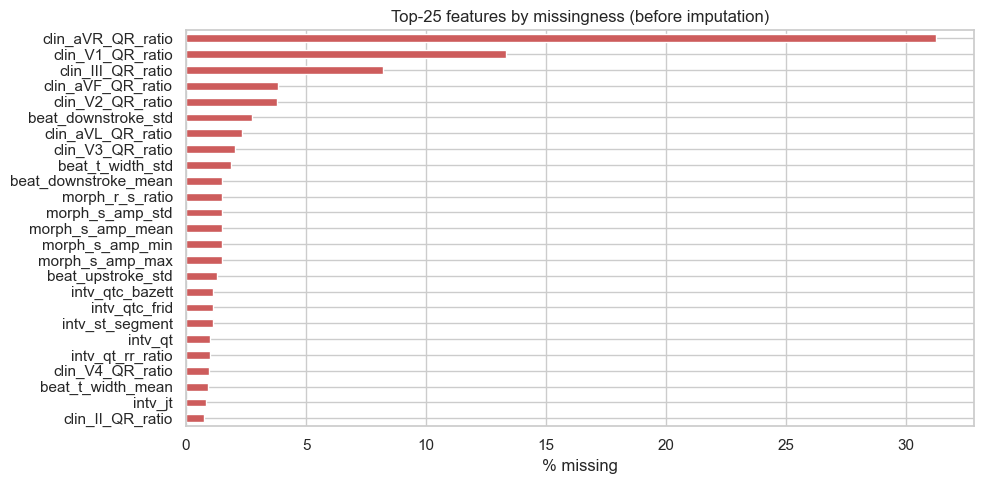

,feature,unit,p5,median,p95,% missing,% inside typical normal range
0,rhythm_heart_rate,bpm,53.37,71.55,104.24,0.00,91.03
1,intv_pr,ms,132.00,172.00,229.00,0.11,80.79
2,intv_qrs,ms,66.00,78.00,120.00,0.03,80.78
3,intv_qt,ms,246.00,362.00,435.00,1.01,75.54
4,intv_qtc_bazett,ms,282.47,395.66,461.92,1.14,82.02
5,intv_qtc_frid,ms,269.76,384.11,444.32,1.14,81.82
6,clin_sokolow_lyon,mV,1.08,2.21,3.85,0.02,91.46
7,clin_qrs_axis,deg,-49.13,19.03,80.98,0.02,85.38


Plausibility on NORM-only records (n = 9069):


,feature,unit,p5,median,p95,% inside typical normal range
0,rhythm_heart_rate,bpm,52.88,69.03,94.89,94.82
1,intv_pr,ms,133.00,169.00,217.00,86.85
2,intv_qrs,ms,64.00,76.00,90.00,84.41
3,intv_qt,ms,316.00,366.00,420.00,89.10
4,intv_qtc_bazett,ms,355.57,392.82,431.76,96.13
5,intv_qtc_frid,ms,351.12,383.04,418.55,95.10
6,clin_sokolow_lyon,mV,1.36,2.24,3.40,96.21
7,clin_qrs_axis,deg,-17.87,32.88,79.84,97.33


QRS plausibility OK: 84 % of NORM-only records have a QRS of 70-110 ms.
Share of beats whose QRS limits came from the spatial-velocity refinement (median over records): 100 %


In [21]:
# 6.1 Missingness
miss = X_all.isna().mean().mul(100).sort_values(ascending=False)
print("Features with > 30 % missing:", int((miss > 30).sum()), "| > 50 %:", int((miss > 50).sum()))
plt.figure(figsize=(10, 5))
miss.head(25).iloc[::-1].plot.barh(color="indianred")
plt.xlabel("% missing"); plt.title("Top-25 features by missingness (before imputation)")
plt.tight_layout(); save_fig("06_missingness.png"); plt.show()

# 6.2 Plausibility of key clinical values
rows = []
for k, (lo, hi, unit) in NORMAL.items():
    v = X_all[k].dropna()
    rows.append({"feature": k, "unit": unit, "p5": v.quantile(.05), "median": v.median(), "p95": v.quantile(.95),
                 "% missing": 100 * X_all[k].isna().mean(),
                 "% inside typical normal range": 100 * v.between(lo, hi).mean()})
plaus = pd.DataFrame(rows).round(2)
plaus.to_csv(os.path.join(TABLE_DIR, "feature_plausibility.csv"), index=False)
display(plaus)

# 6.2b The same check on clean NORM-only records: if the extractor is sane, most of them must have a QRS of 70-110 ms.
norm_only = (Y_all[:, CLASS_NAMES.index("NORM")] == 1) & (Y_all.sum(1) == 1)
rows_n = []
for k, (lo, hi, unit) in NORMAL.items():
    v = X_all.loc[norm_only, k].dropna()
    rows_n.append({"feature": k, "unit": unit, "p5": v.quantile(.05), "median": v.median(), "p95": v.quantile(.95),
                   "% inside typical normal range": 100 * v.between(lo, hi).mean()})
plaus_norm = pd.DataFrame(rows_n).round(2)
plaus_norm.to_csv(os.path.join(TABLE_DIR, "feature_plausibility_norm_only.csv"), index=False)
print(f"Plausibility on NORM-only records (n = {int(norm_only.sum())}):")
display(plaus_norm)
_q = float(plaus_norm.loc[plaus_norm["feature"] == "intv_qrs", "% inside typical normal range"].iloc[0])
if _q < 70:
    print(f"WARNING: only {_q:.0f} % of NORM-only records have a QRS of 70-110 ms. The QRS extractor is still suspect - "
          "inspect the delineation plots before trusting any result below.")
else:
    print(f"QRS plausibility OK: {_q:.0f} % of NORM-only records have a QRS of 70-110 ms.")
print("Share of beats whose QRS limits came from the spatial-velocity refinement (median over records): "
      f"{100 * X_all['intv_qrs_refined_frac'].median():.0f} %")


saved: ../outputs/v5_final\figures\07_key_features_by_class.png


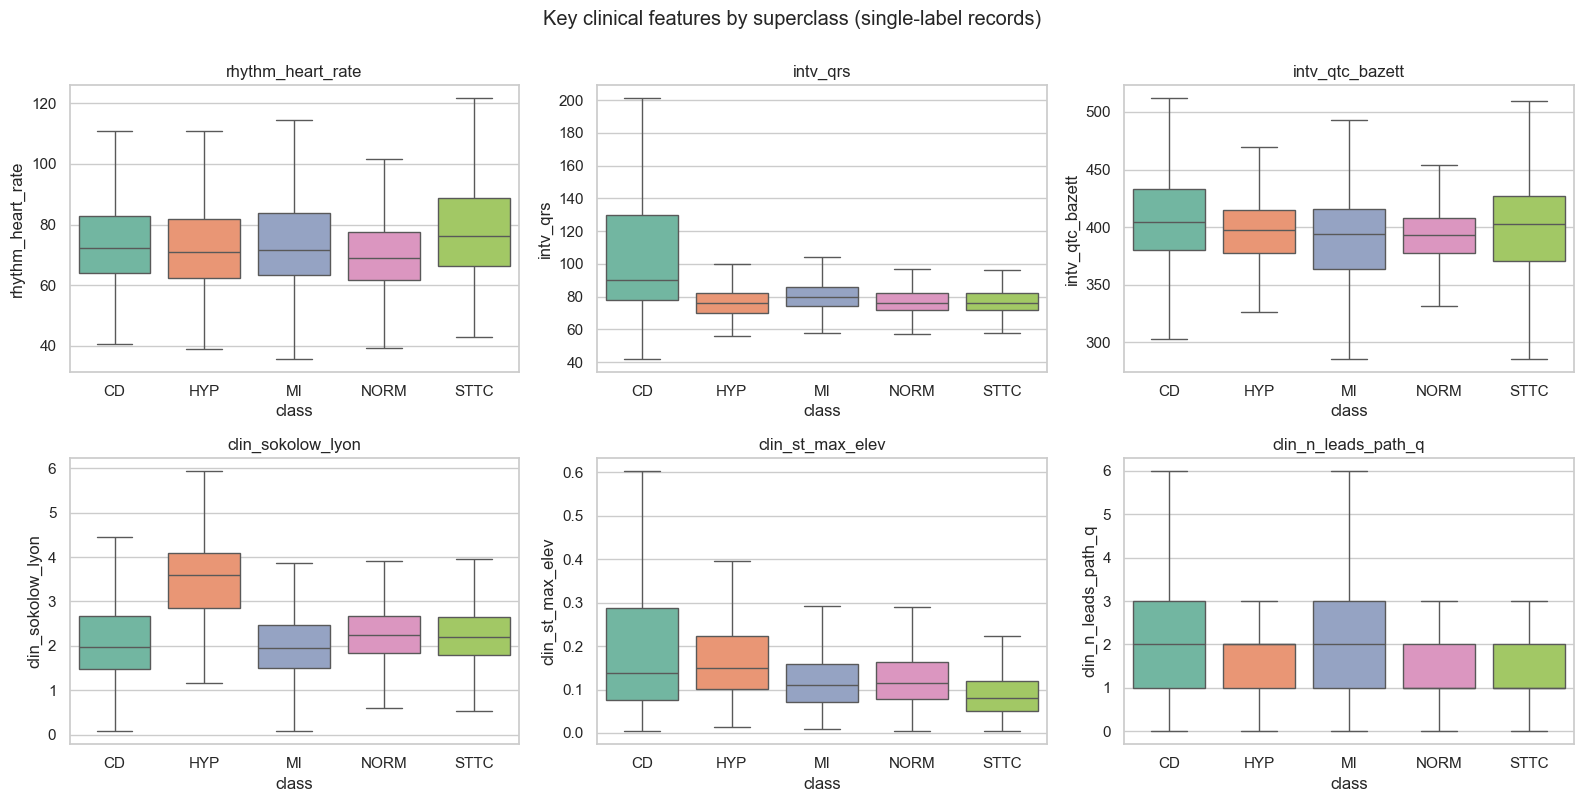

saved: ../outputs/v5_final\figures\08_key_feature_correlation.png


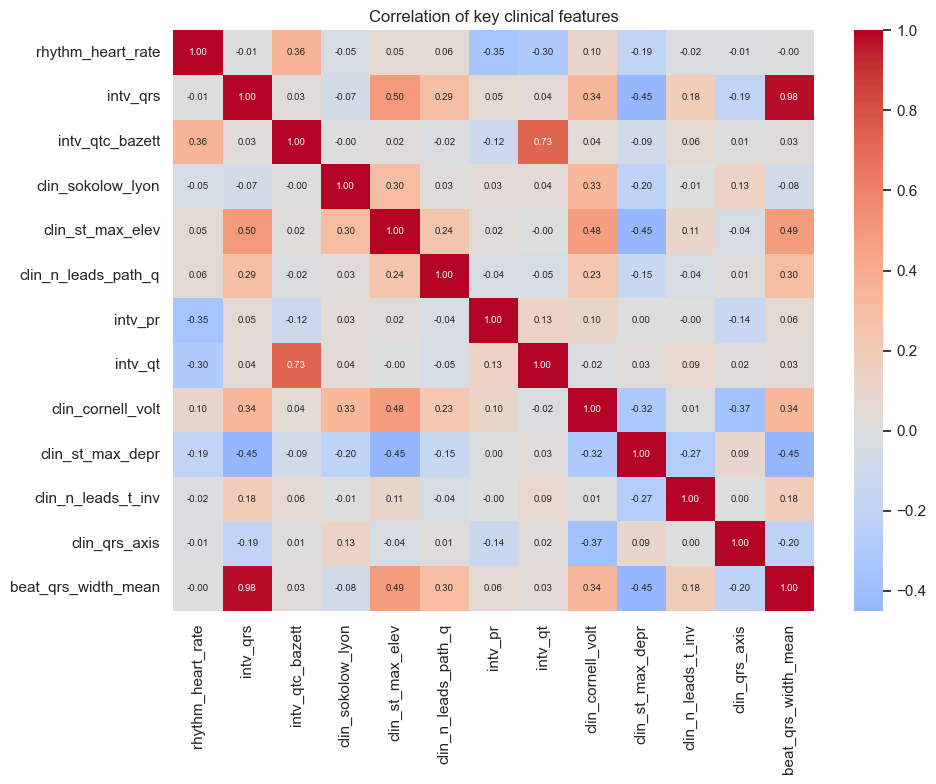

In [22]:
# 6.3 Key clinical features by class (single-label records only, to keep the picture clean)
single_mask = Y_all.sum(1) == 1
cls_single  = np.array(CLASS_NAMES)[Y_all.argmax(1)]
KEY = ["rhythm_heart_rate", "intv_qrs", "intv_qtc_bazett", "clin_sokolow_lyon", "clin_st_max_elev", "clin_n_leads_path_q"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, k in zip(axes.flatten(), KEY):
    d = pd.DataFrame({"class": cls_single[single_mask], k: X_all.loc[single_mask, k].values})
    sns.boxplot(data=d, x="class", y=k, order=CLASS_NAMES, showfliers=False, ax=ax, palette="Set2")
    ax.set_title(k)
plt.suptitle("Key clinical features by superclass (single-label records)", y=1.0)
plt.tight_layout(); save_fig("07_key_features_by_class.png"); plt.show()

# 6.4 Correlation between the key features
corr_cols = KEY + ["intv_pr", "intv_qt", "clin_cornell_volt", "clin_st_max_depr", "clin_n_leads_t_inv",
                   "clin_qrs_axis", "beat_qrs_width_mean"]
plt.figure(figsize=(10, 8))
sns.heatmap(X_all[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7})
plt.title("Correlation of key clinical features"); plt.tight_layout()
save_fig("08_key_feature_correlation.png"); plt.show()

## 7. Official patient-disjoint split

Folds 1–8 train, fold 9 validation (**model selection and threshold tuning only**), fold 10 test
(**reported only, never used for any decision**). PTB-XL's `strat_fold` keeps all records of a patient
in one fold and stratifies labels, which makes results comparable to the published benchmark.

In [23]:
tr, va, te = folds <= 8, folds == 9, folds == 10

X_tr, Y_tr = X_all[tr], Y_all[tr]
X_va, Y_va = X_all[va], Y_all[va]
X_te, Y_te = X_all[te], Y_all[te]
PAT_TR = patients[tr]
PAT_TE = patients[te]

print(f"Train : {tr.sum():6d} records  (folds 1-8)")
print(f"Val   : {va.sum():6d} records  (fold 9)")
print(f"Test  : {te.sum():6d} records  (fold 10)")

p_tr, p_va, p_te = set(patients[tr]), set(patients[va]), set(patients[te])
assert not (p_tr & p_va) and not (p_tr & p_te) and not (p_va & p_te), "patient leakage between splits"
print("\nNo patient appears in more than one split.")
print("\nPositives per class:")
print(pd.DataFrame({"train": Y_tr.sum(0), "val": Y_va.sum(0), "test": Y_te.sum(0)}, index=CLASS_NAMES).to_string())

Train :  17084 records  (folds 1-8)
Val   :   2146 records  (fold 9)
Test  :   2158 records  (fold 10)

No patient appears in more than one split.

Positives per class:
      train  val  test
CD     3907  495   496
HYP    2119  268   262
MI     4379  540   550
NORM   7596  955   963
STTC   4186  528   521


## 8. Leak-free preprocessing pipeline

All steps are fitted on the **training folds only** and then applied unchanged to validation and test:

1. `MissingFilter` — drop features missing in more than 50 % of training records
2. Median imputation
3. Drop exactly-constant features
4. `QuantileClipper` — clip each feature to its training 0.5–99.5 percentile (tames outliers from failed detections)
5. `CorrelationPruner` — for every pair with |r| > 0.95 keep the earlier column (clinical blocks come first, so they win over generic statistics)
6. Standardisation

In [24]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler


class MissingFilter(BaseEstimator, TransformerMixin):
    def __init__(self, max_frac=0.5):
        self.max_frac = max_frac
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.keep_idx_ = np.flatnonzero(np.isnan(X).mean(axis=0) <= self.max_frac)
        return self
    def transform(self, X):
        return np.asarray(X, dtype=float)[:, self.keep_idx_]


class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.005, upper=0.995):
        self.lower, self.upper = lower, upper
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_ = np.nanquantile(X, self.lower, axis=0)
        self.hi_ = np.nanquantile(X, self.upper, axis=0)
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lo_, self.hi_)


class CorrelationPruner(BaseEstimator, TransformerMixin):
    # Drop one feature of every pair with |Pearson r| > threshold; keeps the earlier column.
    def __init__(self, threshold=0.95):
        self.threshold = threshold
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        corr = np.abs(np.corrcoef(X, rowvar=False))
        corr = np.nan_to_num(corr, nan=0.0)
        n, drop = corr.shape[0], set()
        for i in range(n):
            if i in drop:
                continue
            for j in range(i + 1, n):
                if j not in drop and corr[i, j] > self.threshold:
                    drop.add(j)
        self.keep_idx_ = np.array([i for i in range(n) if i not in drop], dtype=int)
        return self
    def transform(self, X):
        return np.asarray(X, dtype=float)[:, self.keep_idx_]


def make_preprocessor(corr_threshold=0.95):
    return Pipeline([
        ("missing", MissingFilter(max_frac=0.5)),
        ("impute",  SimpleImputer(strategy="median")),
        ("var",     VarianceThreshold(threshold=0.0)),
        ("clip",    QuantileClipper()),
        ("corr",    CorrelationPruner(threshold=corr_threshold)),
        ("scale",   StandardScaler()),
    ])


def fitted_feature_names(pre, input_names):
    # Follow the surviving column names through every selecting step of the fitted pipeline.
    names = np.asarray(input_names)
    for _, step in pre.steps:
        if hasattr(step, "keep_idx_"):
            names = names[step.keep_idx_]
        elif hasattr(step, "get_support"):
            names = names[step.get_support()]
    return list(names)


pre = make_preprocessor()
Xtr_p = pre.fit_transform(X_tr)          # fitted on TRAIN only
Xva_p = pre.transform(X_va)
Xte_p = pre.transform(X_te)
FEAT_NAMES = fitted_feature_names(pre, X_all.columns)
assert len(FEAT_NAMES) == Xtr_p.shape[1], "feature-name bookkeeping is out of sync with the matrix"

print(f"{X_all.shape[1]} features in  ->  {Xtr_p.shape[1]} after preprocessing")
print("Removed:", X_all.shape[1] - Xtr_p.shape[1])
print("Kept per block:", pd.Series([n.split('_')[0] for n in FEAT_NAMES]).value_counts().to_dict())
pd.DataFrame({"feature": FEAT_NAMES}).to_csv(os.path.join(TABLE_DIR, "final_feature_names.csv"), index=False)

322 features in  ->  274 after preprocessing
Removed: 48
Kept per block: {'clin': 135, 'lead': 70, 'morph': 26, 'intv': 14, 'pwave': 8, 'rhythm': 8, 'beat': 8, 'freq': 5}


## 9. Models

One-vs-rest across the five superclasses, class imbalance handled explicitly:
`class_weight="balanced"` (LR), `"balanced_subsample"` (RF) and a **per-class `scale_pos_weight`** for XGBoost
(via the small `XGBMultiLabel` wrapper below). Every model exposes `predict_proba` → `(n_samples, 5)`.

A fourth model, **`XGBClassifierChain`**, targets label co-occurrence directly: ~24 % of records carry
2 or more superclasses, information a plain one-vs-rest model never uses when scoring one class against
another. The chain fits one XGBoost per label, in **rarest-class-first order**, and each stage receives the
**out-of-fold** predicted probabilities of every earlier-placed label as extra input columns (never in-sample
predictions — that would leak), computed with **patient-grouped** stratified folds so that the records of one patient
never sit on both sides of an inner split. At inference the chain feeds its own earlier-stage test-time probabilities
forward the same way. `predict_proba` always returns columns in the original `CLASS_NAMES` order regardless
of the internal chain order.

In [25]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


class XGBMultiLabel(BaseEstimator):
    # One XGBClassifier per label with its own scale_pos_weight (= negatives / positives).
    def __init__(self, n_estimators=400, learning_rate=0.05, max_depth=6, subsample=0.8,
                 colsample_bytree=0.8, min_child_weight=2, reg_lambda=1.0,
                 use_pos_weight=True, random_state=42, n_jobs=-1):
        self.n_estimators, self.learning_rate, self.max_depth = n_estimators, learning_rate, max_depth
        self.subsample, self.colsample_bytree = subsample, colsample_bytree
        self.min_child_weight, self.reg_lambda = min_child_weight, reg_lambda
        self.use_pos_weight, self.random_state, self.n_jobs = use_pos_weight, random_state, n_jobs

    def fit(self, X, Y):
        Y = np.asarray(Y)
        self.estimators_, self.pos_weight_ = [], []
        for j in range(Y.shape[1]):
            pos = float(Y[:, j].sum()); neg = float(len(Y) - pos)
            spw = neg / max(pos, 1.0) if self.use_pos_weight else 1.0
            clf = XGBClassifier(
                n_estimators=self.n_estimators, learning_rate=self.learning_rate, max_depth=self.max_depth,
                subsample=self.subsample, colsample_bytree=self.colsample_bytree,
                min_child_weight=self.min_child_weight, reg_lambda=self.reg_lambda,
                scale_pos_weight=spw, objective="binary:logistic", eval_metric="logloss",
                random_state=self.random_state, n_jobs=self.n_jobs)
            clf.fit(X, Y[:, j])
            self.estimators_.append(clf); self.pos_weight_.append(spw)
        return self

    def predict_proba(self, X):
        return np.column_stack([e.predict_proba(X)[:, 1] for e in self.estimators_])


from sklearn.model_selection import StratifiedGroupKFold


def _make_xgb(spw, n_estimators, learning_rate, max_depth, subsample, colsample_bytree,
              min_child_weight, reg_lambda, random_state, n_jobs):
    return XGBClassifier(
        n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth,
        subsample=subsample, colsample_bytree=colsample_bytree, min_child_weight=min_child_weight,
        reg_lambda=reg_lambda, scale_pos_weight=spw, objective="binary:logistic",
        eval_metric="logloss", random_state=random_state, n_jobs=n_jobs)


class XGBClassifierChain(BaseEstimator):
    # Probabilistic classifier chain of per-label XGBoosts. Chain-position features are the
    # OUT-OF-FOLD predicted probability of every earlier label in the chain (never an in-sample
    # prediction, which would leak the very label the model is trying to predict). At inference
    # the chain reuses its own already-fitted earlier stages, in the same order, on new data.
    def __init__(self, order=None, n_splits=5, n_estimators=400, learning_rate=0.05, max_depth=6,
                 subsample=0.8, colsample_bytree=0.8, min_child_weight=2, reg_lambda=1.0,
                 random_state=42, n_jobs=-1):
        self.order, self.n_splits = order, n_splits
        self.n_estimators, self.learning_rate, self.max_depth = n_estimators, learning_rate, max_depth
        self.subsample, self.colsample_bytree = subsample, colsample_bytree
        self.min_child_weight, self.reg_lambda = min_child_weight, reg_lambda
        self.random_state, self.n_jobs = random_state, n_jobs

    def fit(self, X, Y, groups=None):
        # groups: patient id per row. Inner out-of-fold folds keep every patient on ONE side (no patient leakage).
        X = np.asarray(X, dtype=float); Y = np.asarray(Y, dtype=int)
        n, k = Y.shape
        groups = np.arange(n) if groups is None else np.asarray(groups)
        # Default order: rarest class first (the class most starved of positives benefits
        # most from being conditioned on nothing, while later, commoner classes get to see
        # the rarer ones' out-of-fold probabilities as extra signal).
        self.order_ = list(np.argsort(Y.sum(axis=0))) if self.order is None else list(self.order)

        oof = np.zeros((n, k), dtype=float)             # out-of-fold probs, columns in self.order_ position
        self.estimators_ = [None] * k                    # final (full-data) estimator per chain position
        self.pos_weight_ = [None] * k
        skf = StratifiedGroupKFold(n_splits=self.n_splits, shuffle=True, random_state=self.random_state)

        for pos, j in enumerate(self.order_):
            extra_cols = self.order_[:pos]                                     # earlier chain positions
            Xj = np.hstack([X] + [oof[:, [c]] for c in extra_cols]) if extra_cols else X
            y = Y[:, j]
            pos_n, neg_n = float(y.sum()), float(len(y) - y.sum())
            spw = neg_n / max(pos_n, 1.0)

            # --- out-of-fold probabilities for THIS stage, to hand to later stages ---
            fold_probs = np.zeros(n, dtype=float)
            for tr_idx, va_idx in skf.split(Xj, y, groups):
                clf_f = _make_xgb(spw, self.n_estimators, self.learning_rate, self.max_depth,
                                  self.subsample, self.colsample_bytree, self.min_child_weight,
                                  self.reg_lambda, self.random_state, self.n_jobs)
                clf_f.fit(Xj[tr_idx], y[tr_idx])
                fold_probs[va_idx] = clf_f.predict_proba(Xj[va_idx])[:, 1]
            oof[:, j] = fold_probs

            # --- final estimator for this stage, fit on ALL training data, used at inference ---
            clf = _make_xgb(spw, self.n_estimators, self.learning_rate, self.max_depth,
                            self.subsample, self.colsample_bytree, self.min_child_weight,
                            self.reg_lambda, self.random_state, self.n_jobs)
            clf.fit(Xj, y)
            self.estimators_[j] = clf
            self.pos_weight_[j] = spw
        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        n, k = X.shape[0], len(self.order_)
        probs = np.zeros((n, k), dtype=float)
        for pos, j in enumerate(self.order_):
            extra_cols = self.order_[:pos]
            Xj = np.hstack([X] + [probs[:, [c]] for c in extra_cols]) if extra_cols else X
            probs[:, j] = self.estimators_[j].predict_proba(Xj)[:, 1]
        return probs                                        # columns already in original CLASS_NAMES order


models = {
    "Logistic Regression": OneVsRestClassifier(
        LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)),
    "Random Forest": OneVsRestClassifier(
        RandomForestClassifier(n_estimators=500, min_samples_leaf=2, class_weight="balanced_subsample",
                               random_state=RANDOM_STATE, n_jobs=-1)),
    "XGBoost": XGBMultiLabel(random_state=RANDOM_STATE),
    "XGBoost Chain": XGBClassifierChain(random_state=RANDOM_STATE),
}

fitted, probas = {}, {}
for name, mdl in models.items():
    t0 = time.time()
    if isinstance(mdl, XGBClassifierChain):
        mdl.fit(Xtr_p, Y_tr, groups=PAT_TR)
    else:
        mdl.fit(Xtr_p, Y_tr)
    fitted[name] = mdl
    probas[name] = {"val": mdl.predict_proba(Xva_p), "test": mdl.predict_proba(Xte_p)}
    assert probas[name]["val"].shape == (len(Y_va), len(CLASS_NAMES))
    print(f"{name:22s} trained in {time.time() - t0:6.1f} s")
print("\nXGBoost scale_pos_weight per class:",
      {c: round(w, 2) for c, w in zip(CLASS_NAMES, fitted["XGBoost"].pos_weight_)})
print("Chain order (rarest first):", [CLASS_NAMES[j] for j in fitted["XGBoost Chain"].order_])

Logistic Regression    trained in    4.0 s
Random Forest          trained in  144.8 s
XGBoost                trained in   30.5 s
XGBoost Chain          trained in  200.4 s

XGBoost scale_pos_weight per class: {'CD': 3.37, 'HYP': 7.06, 'MI': 2.9, 'NORM': 1.25, 'STTC': 3.08}
Chain order (rarest first): ['HYP', 'CD', 'STTC', 'MI', 'NORM']


## 10. Evaluation

Reported the way the PTB-XL literature reports it: **macro AUC** (headline), per-class AUC, and
sample-centric **Fmax**, with 95 % confidence intervals from a **patient-level bootstrap**.

* Model selection: highest macro AUC on the **validation fold**; if a simpler model is within `SELECTION_TOL` of it,
  the simpler model is taken (order: LR < RF < XGBoost < XGBoost Chain).
* Decision thresholds: chosen on the **validation fold**, then applied unchanged to the test fold.
  Two policies are computed for every model — **F1-optimal** (maximises F1 per class) and
  **precision-targeted** (the highest threshold that still keeps recall $\ge$ `RECALL_FLOOR`, but
  **never below the F1-optimal threshold**, so it can only make a class more conservative). The active
  policy is set by `THRESHOLD_POLICY`; both are reported for the selected model so the trade-off is visible.
* Test fold 10 is only ever *reported*.

Published deep-learning baselines on this task reach a macro AUC of about 0.92–0.93
(Strodthoff et al., IEEE JBHI 2021). A hand-crafted-feature model is expected to land below that;
report whatever you get.

In [26]:
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, precision_score, roc_curve,
                             precision_recall_curve, confusion_matrix, recall_score, balanced_accuracy_score)

def macro_auc(Y, P):
    return float(np.mean([roc_auc_score(Y[:, i], P[:, i]) for i in range(Y.shape[1])]))

def fmax_sample_centric(Y, P, grid=np.linspace(0.01, 0.99, 99)):
    # CAFA-style: precision averaged over samples with >=1 predicted label, recall over all samples.
    ntrue, best = np.maximum(Y.sum(1), 1), 0.0
    for t in grid:
        pred = P >= t
        tp, npred = (pred & (Y == 1)).sum(1), pred.sum(1)
        has = npred > 0
        if not has.any():
            continue
        prec, rec = np.mean(tp[has] / npred[has]), np.mean(tp / ntrue)
        if prec + rec > 0:
            best = max(best, 2 * prec * rec / (prec + rec))
    return float(best)

def cluster_bootstrap_ci(Y, P, groups, fn, n_boot=1000, seed=RANDOM_STATE):
    # Resample PATIENTS (not records) with replacement: records of one patient are correlated.
    rng = np.random.default_rng(seed)
    uniq, inv = np.unique(groups, return_inverse=True)
    members = [np.flatnonzero(inv == k) for k in range(len(uniq))]
    vals = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(uniq), len(uniq))
        idx = np.concatenate([members[k] for k in pick])
        Yb = Y[idx]
        if (Yb.sum(0) == 0).any() or (Yb.sum(0) == len(Yb)).any():
            continue
        vals.append(fn(Yb, P[idx]))
    lo, hi = np.percentile(vals, [2.5, 97.5])
    return float(lo), float(hi)

def per_class_thresholds(Y, P):
    # F1-optimal per class.
    grid = np.linspace(0.05, 0.95, 91)
    return np.array([grid[int(np.argmax([f1_score(Y[:, i], (P[:, i] >= t).astype(int), zero_division=0)
                                         for t in grid]))] for i in range(Y.shape[1])])

def per_class_thresholds_precision_target(Y, P, min_recall=0.70, by_class=None):
    # Precision-oriented thresholds. Per class: the HIGHEST threshold whose validation recall is still >= the recall floor,
    # but NEVER BELOW the F1-optimal threshold. The policy can therefore only make a class more conservative than the
    # F1-optimal point (the previous version lowered thresholds when the F1-optimal recall was under the floor,
    # which cost precision).
    grid = np.linspace(0.05, 0.95, 91)
    f1_thr = per_class_thresholds(Y, P)
    out = np.empty(Y.shape[1])
    for i in range(Y.shape[1]):
        floor = (by_class or {}).get(CLASS_NAMES[i], min_recall)
        y = Y[:, i]
        n_pos = max(int(y.sum()), 1)
        feasible = [t for t in grid if ((P[:, i] >= t) & (y == 1)).sum() / n_pos >= floor]
        out[i] = max(f1_thr[i], max(feasible)) if feasible else f1_thr[i]
    return out


# thresholds are tuned on VALIDATION for every model, once, under both policies
THRESHOLDS           = {name: per_class_thresholds(Y_va, probas[name]["val"]) for name in models}
THRESHOLDS_PRECISION = {name: per_class_thresholds_precision_target(Y_va, probas[name]["val"], RECALL_FLOOR, RECALL_FLOOR_BY_CLASS)
                        for name in models}
POLICY_THRESHOLDS    = {"f1": THRESHOLDS, "precision_target": THRESHOLDS_PRECISION}
ACTIVE_THRESHOLDS    = POLICY_THRESHOLDS[THRESHOLD_POLICY]
print(f"Active threshold policy: {THRESHOLD_POLICY}" +
      (f" (recall floor {RECALL_FLOOR}, per-class overrides {RECALL_FLOOR_BY_CLASS}; never below the F1-optimal threshold)"
       if THRESHOLD_POLICY == "precision_target" else ""))

Active threshold policy: precision_target (recall floor 0.7, per-class overrides {}; never below the F1-optimal threshold)


In [27]:
rows = []
for name in models:
    pv, pt = probas[name]["val"], probas[name]["test"]
    yhat = (pt >= ACTIVE_THRESHOLDS[name]).astype(int)          # val thresholds -> test predictions
    lo, hi = cluster_bootstrap_ci(Y_te, pt, PAT_TE, macro_auc)
    rows.append({
        "Model": name,
        "Val macro AUC": macro_auc(Y_va, pv),
        "Test macro AUC": macro_auc(Y_te, pt),
        "Test AUC 95% CI": f"[{lo:.3f}, {hi:.3f}]",
        "Test Fmax": fmax_sample_centric(Y_te, pt),
        "Test macro F1": f1_score(Y_te, yhat, average="macro", zero_division=0),
        "Test micro F1": f1_score(Y_te, yhat, average="micro", zero_division=0),
        "Test macro precision": precision_score(Y_te, yhat, average="macro", zero_division=0),
        "Test macro recall": recall_score(Y_te, yhat, average="macro", zero_division=0),
        "Test macro accuracy": float((yhat == Y_te).mean()),                  # mean per-label accuracy
        "Test exact-match acc": float((yhat == Y_te).all(axis=1).mean()),     # all 5 labels right (strict)
        "Test macro AP": float(np.mean([average_precision_score(Y_te[:, i], pt[:, i]) for i in range(len(CLASS_NAMES))])),
    })

results_df = pd.DataFrame(rows).sort_values("Val macro AUC", ascending=False).reset_index(drop=True)
# Selection on VALIDATION only: the simplest model within SELECTION_TOL of the best validation macro AUC wins.
SIMPLICITY = ["Logistic Regression", "Random Forest", "XGBoost", "XGBoost Chain"]       # simplest -> most complex
_top = results_df["Val macro AUC"].max()
_eligible = results_df.loc[results_df["Val macro AUC"] >= _top - SELECTION_TOL, "Model"].tolist()
BEST = min(_eligible, key=SIMPLICITY.index)
results_df.to_csv(os.path.join(TABLE_DIR, "model_comparison.csv"), index=False)
display(results_df.round(4))
print(f"Best validation macro AUC: {_top:.4f} | candidates within {SELECTION_TOL}: {_eligible}")
print(f"Selected model (simplest within tolerance of the best validation macro AUC): {BEST}")
print("Published deep-learning reference: macro AUC ~ 0.92-0.93")

,Model,Val macro AUC,Test macro AUC,Test AUC 95% CI,Test Fmax,Test macro F1,Test micro F1,Test macro precision,Test macro recall,Test macro accuracy,Test exact-match acc,Test macro AP
0,XGBoost,0.9333,0.9251,"[0.918, 0.932]",0.8024,0.7178,0.7373,0.7861,0.6666,0.8753,0.5385,0.8175
1,XGBoost Chain,0.9329,0.9249,"[0.918, 0.932]",0.8040,0.7141,0.7339,0.7803,0.6644,0.8736,0.5408,0.8166
2,Random Forest,0.9264,0.9196,"[0.912, 0.927]",0.7977,0.7103,0.7289,0.7416,0.6944,0.8665,0.5232,0.8001
3,Logistic Regression,0.9016,0.8882,"[0.879, 0.897]",0.7471,0.6727,0.6960,0.6864,0.6727,0.8463,0.4741,0.7324


Best validation macro AUC: 0.9333 | candidates within 0.003: ['XGBoost', 'XGBoost Chain']
Selected model (simplest within tolerance of the best validation macro AUC): XGBoost
Published deep-learning reference: macro AUC ~ 0.92-0.93


In [28]:
pt, pv = probas[BEST]["test"], probas[BEST]["val"]
ths    = ACTIVE_THRESHOLDS[BEST]
yhat   = (pt >= ths).astype(int)

per_class = []
for i, c in enumerate(CLASS_NAMES):
    lo, hi = cluster_bootstrap_ci(Y_te[:, [i]], pt[:, [i]], PAT_TE, lambda a, b: roc_auc_score(a[:, 0], b[:, 0]))
    tp = int(((yhat[:, i] == 1) & (Y_te[:, i] == 1)).sum())
    fp = int(((yhat[:, i] == 1) & (Y_te[:, i] == 0)).sum())
    fn = int(((yhat[:, i] == 0) & (Y_te[:, i] == 1)).sum())
    tn = int(((yhat[:, i] == 0) & (Y_te[:, i] == 0)).sum())
    per_class.append({
        "Class": c, "Support": int(Y_te[:, i].sum()), "Threshold": round(float(ths[i]), 2),
        "AUC": roc_auc_score(Y_te[:, i], pt[:, i]), "AUC 95% CI": f"[{lo:.3f}, {hi:.3f}]",
        "AP": average_precision_score(Y_te[:, i], pt[:, i]),
        "Precision": tp / max(tp + fp, 1), "Recall (sens.)": tp / max(tp + fn, 1),
        "Specificity": tn / max(tn + fp, 1),
        "Accuracy": (tp + tn) / len(Y_te),
        "Balanced acc.": 0.5 * (tp / max(tp + fn, 1) + tn / max(tn + fp, 1)),
        "F1": f1_score(Y_te[:, i], yhat[:, i], zero_division=0),
        "F1 @0.5": f1_score(Y_te[:, i], (pt[:, i] >= 0.5).astype(int), zero_division=0),
    })
per_class_df = pd.DataFrame(per_class)
per_class_df.to_csv(os.path.join(TABLE_DIR, "per_class_results.csv"), index=False)
print(f"Per-class results - {BEST} (test = fold 10, thresholds from fold 9, policy = {THRESHOLD_POLICY})")
display(per_class_df.round(4))

Per-class results - XGBoost (test = fold 10, thresholds from fold 9, policy = precision_target)


,Class,Support,Threshold,AUC,AUC 95% CI,AP,Precision,Recall (sens.),Specificity,Accuracy,Balanced acc.,F1,F1 @0.5
0,CD,496,0.70,0.9151,"[0.898, 0.932]",0.8407,0.8678,0.6089,0.9723,0.8888,0.7906,0.7156,0.7453
1,HYP,262,0.42,0.9084,"[0.889, 0.927]",0.6899,0.6028,0.6489,0.9409,0.9055,0.7949,0.6250,0.6255
2,MI,550,0.63,0.9355,"[0.924, 0.945]",0.8503,0.8110,0.6709,0.9465,0.8763,0.8087,0.7343,0.7484
3,NORM,963,0.88,0.9437,"[0.934, 0.952]",0.9205,0.9061,0.7113,0.9406,0.8383,0.8260,0.7970,0.8624
4,STTC,521,0.68,0.9228,"[0.909, 0.934]",0.7860,0.7428,0.6929,0.9236,0.8679,0.8083,0.7170,0.7299


### 10.0 Headline numbers of the selected model (test fold 10)


In [29]:
pt_, yh_ = probas[BEST]["test"], (probas[BEST]["test"] >= ACTIVE_THRESHOLDS[BEST]).astype(int)
headline = {
    "model": BEST, "threshold_policy": THRESHOLD_POLICY,
    "recall_floor": RECALL_FLOOR if THRESHOLD_POLICY == "precision_target" else None,
    "n_test_records": int(len(Y_te)),
    "test_macro_auc": macro_auc(Y_te, pt_),
    "fmax_sample_centric": fmax_sample_centric(Y_te, pt_),
    "macro_precision": float(precision_score(Y_te, yh_, average="macro", zero_division=0)),
    "micro_precision": float(precision_score(Y_te, yh_, average="micro", zero_division=0)),
    "macro_recall": float(recall_score(Y_te, yh_, average="macro", zero_division=0)),
    "macro_f1": float(f1_score(Y_te, yh_, average="macro", zero_division=0)),
    "micro_f1": float(f1_score(Y_te, yh_, average="micro", zero_division=0)),
    "mean_per_label_accuracy": float((yh_ == Y_te).mean()),
    "macro_balanced_accuracy": float(np.mean([balanced_accuracy_score(Y_te[:, i], yh_[:, i]) for i in range(Y_te.shape[1])])),
    "exact_match_accuracy": float((yh_ == Y_te).all(axis=1).mean()),
}
with open(os.path.join(TABLE_DIR, "headline_metrics.json"), "w") as fh:
    json.dump(headline, fh, indent=2)
print(f"FINAL MODEL: {BEST}  |  threshold policy: {THRESHOLD_POLICY}  |  test fold 10 ({len(Y_te)} records)\n")
for k_, v_ in headline.items():
    if isinstance(v_, float):
        print(f"  {k_:26s}: {v_:.4f}")


FINAL MODEL: XGBoost  |  threshold policy: precision_target  |  test fold 10 (2158 records)

  recall_floor              : 0.7000
  test_macro_auc            : 0.9251
  fmax_sample_centric       : 0.8024
  macro_precision           : 0.7861
  micro_precision           : 0.8109
  macro_recall              : 0.6666
  macro_f1                  : 0.7178
  micro_f1                  : 0.7373
  mean_per_label_accuracy   : 0.8753
  macro_balanced_accuracy   : 0.8057
  exact_match_accuracy      : 0.5385


### 10.1 F1-optimal vs. precision-targeted thresholds, side by side

Whichever policy is *active* drives the table above and everything downstream (confusion matrices,
the saved bundle). This side-by-side view is purely diagnostic: it shows what each class's precision
and recall would have been under the *other* policy, so the trade-off being made is explicit rather
than hidden inside a single threshold number. The two `Val` columns show what the thresholds achieved on the fold
they were tuned on, which makes any validation-to-test drop visible.

In [30]:
def policy_table(policy_name, ths_dict):
    ths_ = ths_dict[BEST]
    yhat_ = (pt >= ths_).astype(int)
    yhat_v = (pv >= ths_).astype(int)
    rows_ = []
    for i, c in enumerate(CLASS_NAMES):
        tp = int(((yhat_[:, i] == 1) & (Y_te[:, i] == 1)).sum())
        fp = int(((yhat_[:, i] == 1) & (Y_te[:, i] == 0)).sum())
        fn = int(((yhat_[:, i] == 0) & (Y_te[:, i] == 1)).sum())
        rows_.append({"Class": c, "Policy": policy_name, "Threshold": round(float(ths_[i]), 2),
                      "Precision": tp / max(tp + fp, 1), "Recall": tp / max(tp + fn, 1),
                      "F1": f1_score(Y_te[:, i], yhat_[:, i], zero_division=0),
                      "Val precision": precision_score(Y_va[:, i], yhat_v[:, i], zero_division=0),
                      "Val recall": recall_score(Y_va[:, i], yhat_v[:, i], zero_division=0)})
    return rows_

compare_df = pd.DataFrame(policy_table("F1-optimal", THRESHOLDS) + policy_table("precision_target", THRESHOLDS_PRECISION))
compare_df = compare_df.sort_values(["Class", "Policy"]).reset_index(drop=True)
compare_df.to_csv(os.path.join(TABLE_DIR, "threshold_policy_comparison.csv"), index=False)
display(compare_df.round(3))

,Class,Policy,Threshold,Precision,Recall,F1,Val precision,Val recall
0,CD,F1-optimal,0.57,0.807,0.675,0.735,0.835,0.745
1,CD,precision_target,0.70,0.868,0.609,0.716,0.862,0.705
2,HYP,F1-optimal,0.42,0.603,0.649,0.625,0.613,0.649
3,HYP,precision_target,0.42,0.603,0.649,0.625,0.613,0.649
4,MI,F1-optimal,0.48,0.746,0.744,0.745,0.750,0.769
5,MI,precision_target,0.63,0.811,0.671,0.734,0.797,0.704
6,NORM,F1-optimal,0.61,0.831,0.890,0.860,0.838,0.880
7,NORM,precision_target,0.88,0.906,0.711,0.797,0.920,0.706
8,STTC,F1-optimal,0.55,0.699,0.766,0.731,0.736,0.786
9,STTC,precision_target,0.68,0.743,0.693,0.717,0.765,0.703


saved: ../outputs/v5_final\figures\09_roc_pr_curves.png


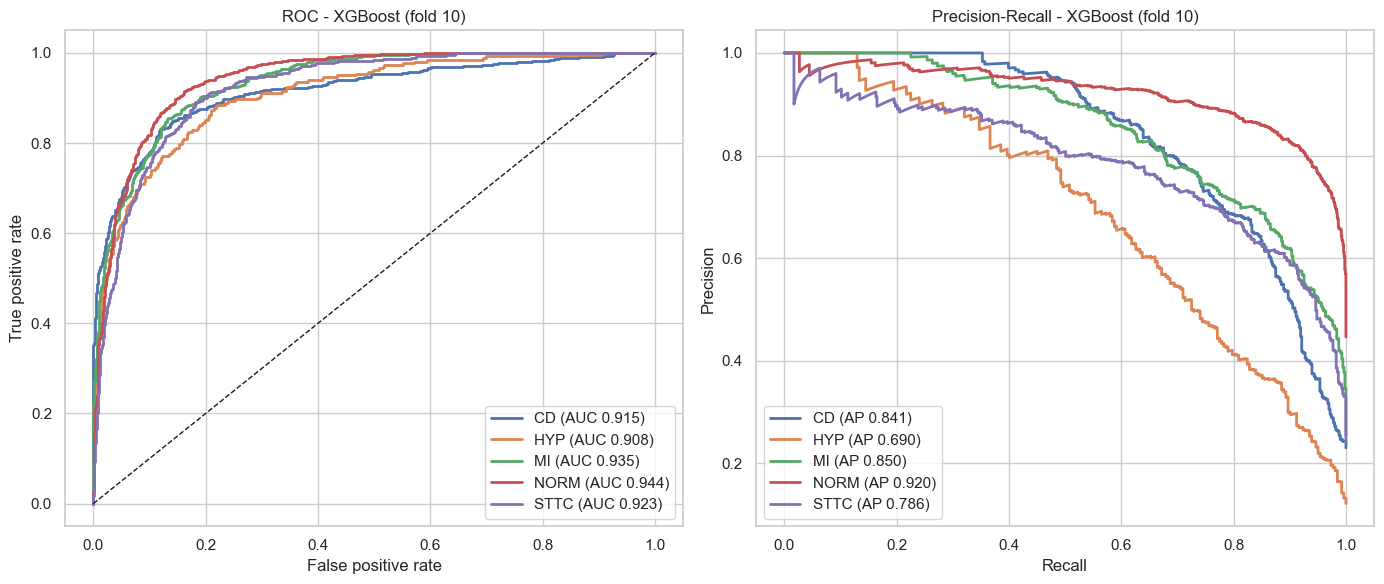

saved: ../outputs/v5_final\figures\10_confusion_matrices.png


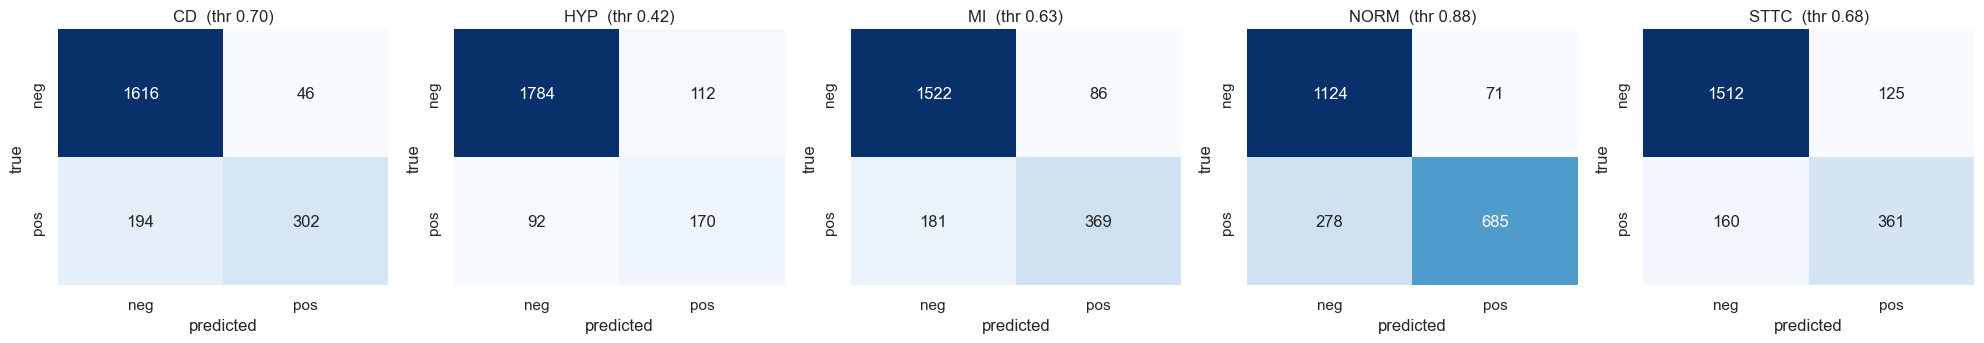

saved: ../outputs/v5_final\figures\11_model_comparison.png


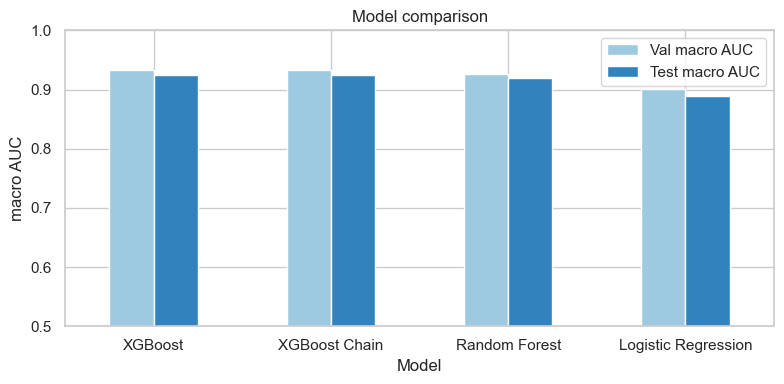

In [31]:
# ROC / PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, c in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(Y_te[:, i], pt[:, i])
    axes[0].plot(fpr, tpr, lw=2, label=f"{c} (AUC {roc_auc_score(Y_te[:, i], pt[:, i]):.3f})")
    prec, rec, _ = precision_recall_curve(Y_te[:, i], pt[:, i])
    axes[1].plot(rec, prec, lw=2, label=f"{c} (AP {average_precision_score(Y_te[:, i], pt[:, i]):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set(xlabel="False positive rate", ylabel="True positive rate", title=f"ROC - {BEST} (fold 10)")
axes[1].set(xlabel="Recall", ylabel="Precision", title=f"Precision-Recall - {BEST} (fold 10)")
axes[0].legend(loc="lower right"); axes[1].legend(loc="lower left")
plt.tight_layout(); save_fig("09_roc_pr_curves.png"); plt.show()

# Per-class confusion matrices at the validation-tuned thresholds
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(4 * len(CLASS_NAMES), 3.6))
for i, (ax, c) in enumerate(zip(axes, CLASS_NAMES)):
    cm = confusion_matrix(Y_te[:, i], yhat[:, i], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
    ax.set_title(f"{c}  (thr {ths[i]:.2f})"); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); save_fig("10_confusion_matrices.png"); plt.show()

# Model comparison
plt.figure(figsize=(8, 4))
m = results_df.set_index("Model")[["Val macro AUC", "Test macro AUC"]]
m.plot.bar(ax=plt.gca(), color=["#9ecae1", "#3182bd"], rot=0)
plt.ylim(0.5, 1.0); plt.ylabel("macro AUC"); plt.title("Model comparison")
plt.tight_layout(); save_fig("11_model_comparison.png"); plt.show()

## 11. Ablation — which feature blocks earn their place

Each block is removed in turn and each is also run alone (XGBoost, `ABLATION_TREES` trees, same
preprocessing recipe refitted on the training folds each time). Reported on the test fold for the
report; **no decision in the pipeline depends on these numbers.**

Ablation finished in 2.9 min


,Setting,n_features,Macro AUC,AUC CD,AUC HYP,AUC MI,AUC NORM,AUC STTC,Delta vs all ECG
0,All ECG blocks,322,0.9253,0.9175,0.9061,0.9364,0.9434,0.9229,0.0000
1,All ECG blocks + age/sex,324,0.9267,0.9175,0.9126,0.9375,0.9444,0.9216,0.0014
2,without rhythm_,309,0.9249,0.9176,0.9082,0.9362,0.9427,0.9200,-0.0003
3,without intv_,307,0.9190,0.8979,0.9044,0.9307,0.9413,0.9205,-0.0063
4,without clin_,165,0.8898,0.8876,0.8934,0.8611,0.9118,0.8949,-0.0355
5,without pwave_,314,0.9238,0.9149,0.9084,0.9345,0.9417,0.9196,-0.0014
6,without morph_,292,0.9239,0.9174,0.9037,0.9336,0.9422,0.9226,-0.0013
7,without beat_,312,0.9253,0.9173,0.9072,0.9361,0.9428,0.9231,0.0000
8,without freq_,317,0.9257,0.9210,0.9062,0.9360,0.9435,0.9216,0.0004
9,without lead_,238,0.9259,0.9190,0.9112,0.9341,0.9437,0.9217,0.0007


saved: ../outputs/v5_final\figures\12_ablation.png


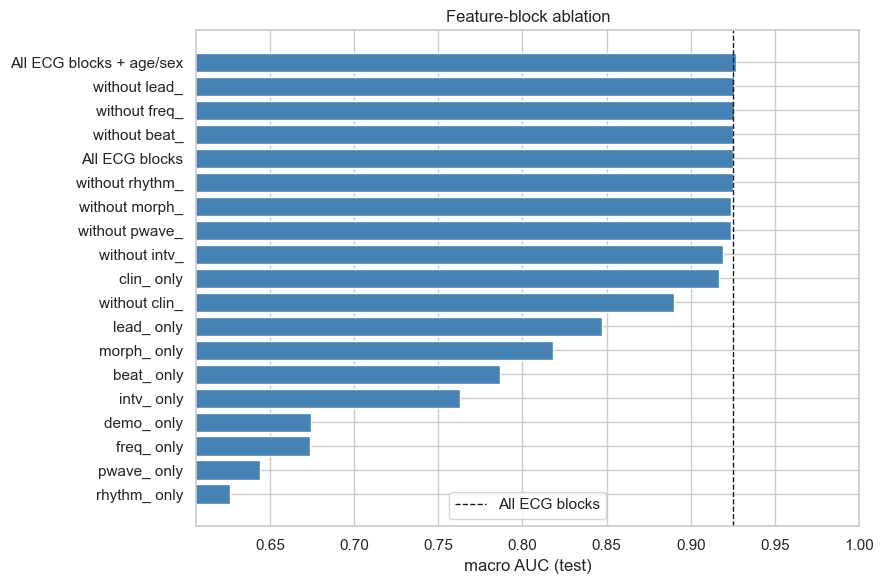

In [32]:
def run_subset(blocks, tag):
    cols = cols_for(blocks)
    if not cols:
        return None
    p_ = make_preprocessor()
    a = p_.fit_transform(X_full.loc[tr, cols].replace([np.inf, -np.inf], np.nan))
    b = p_.transform(X_full.loc[te, cols].replace([np.inf, -np.inf], np.nan))
    m_ = XGBMultiLabel(n_estimators=ABLATION_TREES, random_state=RANDOM_STATE).fit(a, Y_tr)
    P_ = m_.predict_proba(b)
    return {"Setting": tag, "n_features": len(cols), "Macro AUC": macro_auc(Y_te, P_),
            **{f"AUC {c}": roc_auc_score(Y_te[:, i], P_[:, i]) for i, c in enumerate(CLASS_NAMES)}}

t0 = time.time()
abl = [run_subset(ECG_BLOCKS, "All ECG blocks"),
       run_subset(ECG_BLOCKS + ["demo"], "All ECG blocks + age/sex")]
for b in ECG_BLOCKS:
    abl.append(run_subset([x for x in ECG_BLOCKS if x != b], f"without {b}_"))
for b in ECG_BLOCKS + ["demo"]:
    abl.append(run_subset([b], f"{b}_ only"))

ablation = pd.DataFrame([a for a in abl if a])
ablation["Delta vs all ECG"] = ablation["Macro AUC"] - ablation.loc[0, "Macro AUC"]
ablation.to_csv(os.path.join(TABLE_DIR, "ablation.csv"), index=False)
print(f"Ablation finished in {(time.time() - t0) / 60:.1f} min")
display(ablation.round(4))

plt.figure(figsize=(9, 6))
d = ablation.sort_values("Macro AUC")
plt.barh(d["Setting"], d["Macro AUC"], color="steelblue")
plt.axvline(ablation.loc[0, "Macro AUC"], color="k", ls="--", lw=1, label="All ECG blocks")
plt.xlim(max(0.5, d["Macro AUC"].min() - 0.02), 1.0); plt.xlabel("macro AUC (test)")
plt.legend(); plt.title("Feature-block ablation"); plt.tight_layout()
save_fig("12_ablation.png"); plt.show()

## 12. SHAP explainability

Computed with `TreeExplainer` on the **preprocessed (clipped + scaled) matrix the selected tree model (XGBoost or XGBoost Chain) was
trained on**, using a random sample of the test fold. The second half is a *check*, not an assertion:
does the model lean on the clinical criteria that textbooks associate with each class?

In [33]:
import shap

rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(Xte_p.shape[0], size=min(1000, Xte_p.shape[0]), replace=False)
X_shap_base = Xte_p[sample_idx]

# SHAP runs on the SELECTED model when it is tree-based (XGBoost / XGBoost Chain); otherwise on plain XGBoost.
shap_model_name = BEST if isinstance(fitted[BEST], (XGBMultiLabel, XGBClassifierChain)) else "XGBoost"
shap_model = fitted[shap_model_name]
print("SHAP model:", shap_model_name)


def shap_inputs(model, X):
    # Returns, per class (original CLASS_NAMES order), (fitted estimator, input matrix, column names).
    # For the chain, the input of a stage contains the chain-position probabilities of the earlier labels.
    X = np.asarray(X, dtype=float)
    if isinstance(model, XGBClassifierChain):
        probs = np.zeros((X.shape[0], len(model.order_)))
        out = [None] * len(model.order_)
        for pos, j in enumerate(model.order_):
            extra = model.order_[:pos]
            Xj = np.hstack([X] + [probs[:, [c]] for c in extra]) if extra else X
            out[j] = (model.estimators_[j], Xj, list(FEAT_NAMES) + [f"chain_prob_{CLASS_NAMES[c]}" for c in extra])
            probs[:, j] = model.estimators_[j].predict_proba(Xj)[:, 1]
        return out
    return [(est, X, list(FEAT_NAMES)) for est in model.estimators_]


shap_values, shap_frames = {}, {}
for ci, (est, Xj, names) in enumerate(shap_inputs(shap_model, X_shap_base)):
    frame = pd.DataFrame(Xj, columns=names)
    sv = shap.TreeExplainer(est).shap_values(frame)
    shap_values[CLASS_NAMES[ci]] = sv[1] if isinstance(sv, list) else sv
    shap_frames[CLASS_NAMES[ci]] = frame
print("SHAP computed on", X_shap_base.shape[0], "records")

top_tables = {}
for c in CLASS_NAMES:
    imp = pd.DataFrame({"Feature": shap_frames[c].columns, "Mean_abs_SHAP": np.abs(shap_values[c]).mean(axis=0)}
                       ).sort_values("Mean_abs_SHAP", ascending=False).reset_index(drop=True)
    imp["Block"] = imp["Feature"].str.split("_").str[0]
    imp.to_csv(os.path.join(SHAP_DIR, f"{c}_shap_importance.csv"), index=False)
    top_tables[c] = imp
    print(f"\nTop 10 - {c}")
    print(imp.head(10).round(4).to_string(index=False))


SHAP model: XGBoost
SHAP computed on 1000 records

Top 10 - CD
         Feature  Mean_abs_SHAP Block
        intv_qrs         0.6067  intv
       clin_V1_J         0.5101  clin
    clin_V1_area         0.2684  clin
         intv_pr         0.2681  intv
       clin_V2_J         0.2278  clin
    clin_II_area         0.2055  clin
 intv_pr_segment         0.1700  intv
clin_II_RS_ratio         0.1468  clin
    clin_V1_ST60         0.1445  clin
 morph_r_s_ratio         0.1364 morph

Top 10 - HYP
          Feature  Mean_abs_SHAP Block
clin_sokolow_lyon         0.7038  clin
clin_st60_lat_min         0.2486  clin
      lead_V1_std         0.2078  lead
     clin_V6_area         0.1889  clin
      lead_V1_max         0.1353  lead
          intv_pr         0.1328  intv
     pwave_V1_neg         0.1325 pwave
     pwave_V1_ptf         0.1176 pwave
     pwave_II_pos         0.1118 pwave
 morph_p_amp_mean         0.1017 morph

Top 10 - MI
          Feature  Mean_abs_SHAP Block
        clin_V2_R       

saved: ../outputs/v5_final\figures\13_shap_beeswarm_CD.png


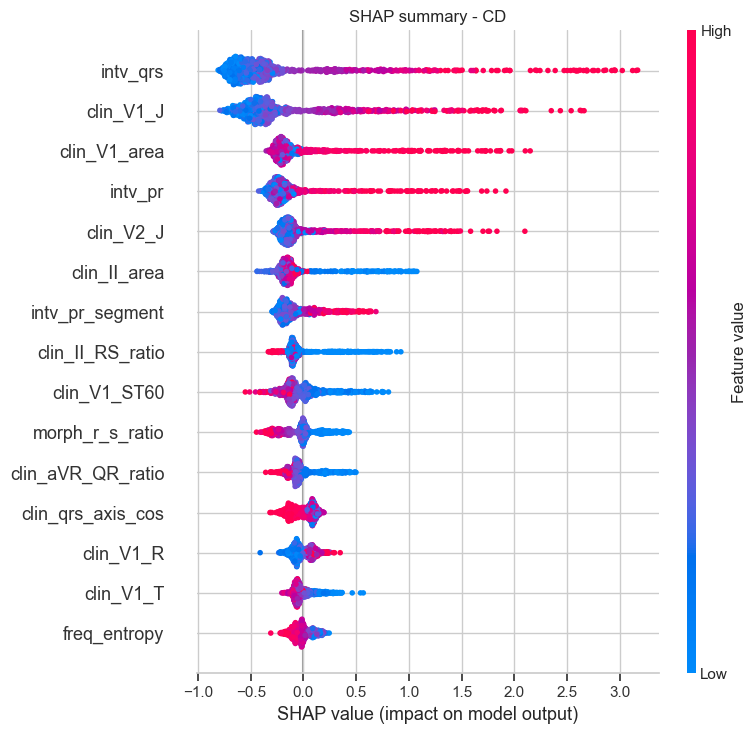

saved: ../outputs/v5_final\figures\13_shap_beeswarm_HYP.png


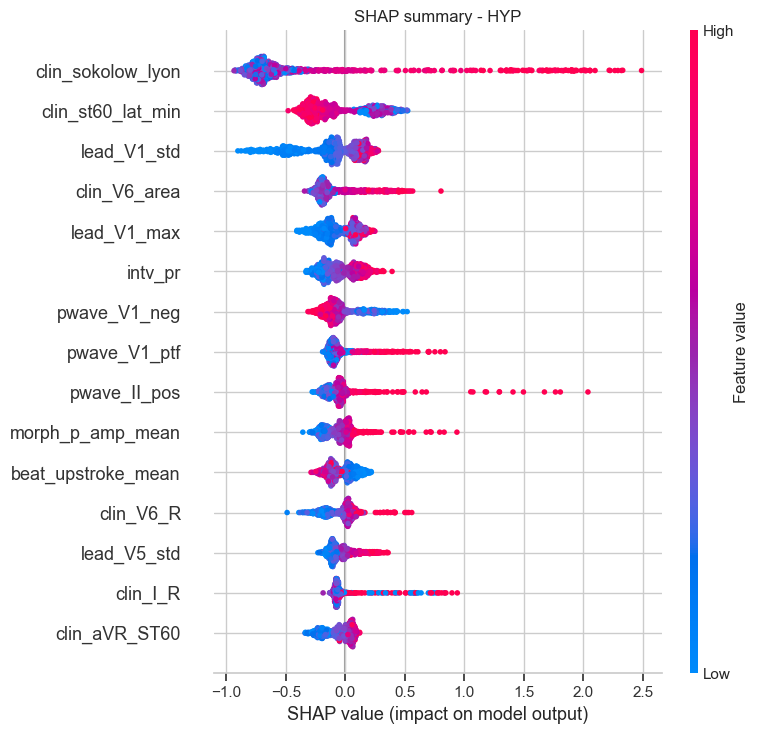

saved: ../outputs/v5_final\figures\13_shap_beeswarm_MI.png


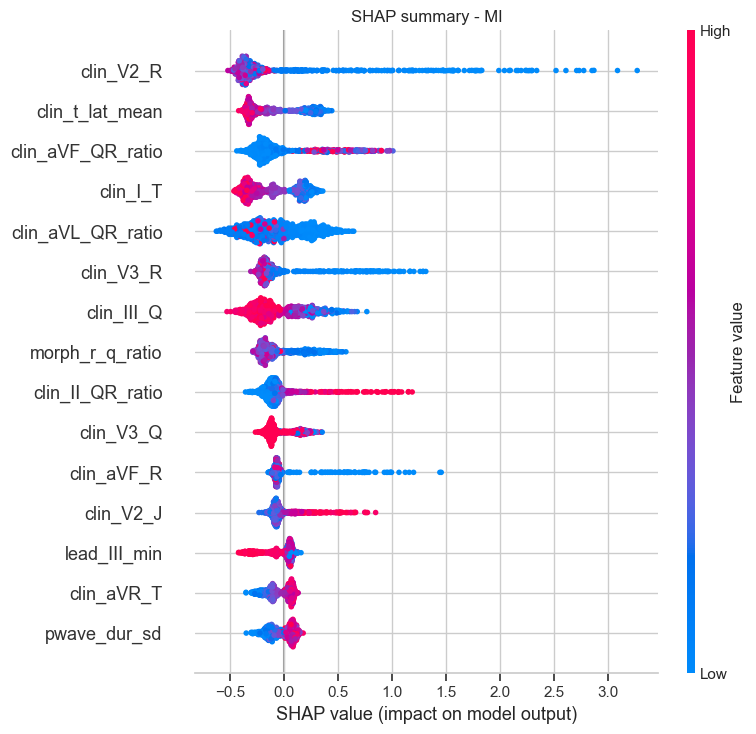

saved: ../outputs/v5_final\figures\13_shap_beeswarm_NORM.png


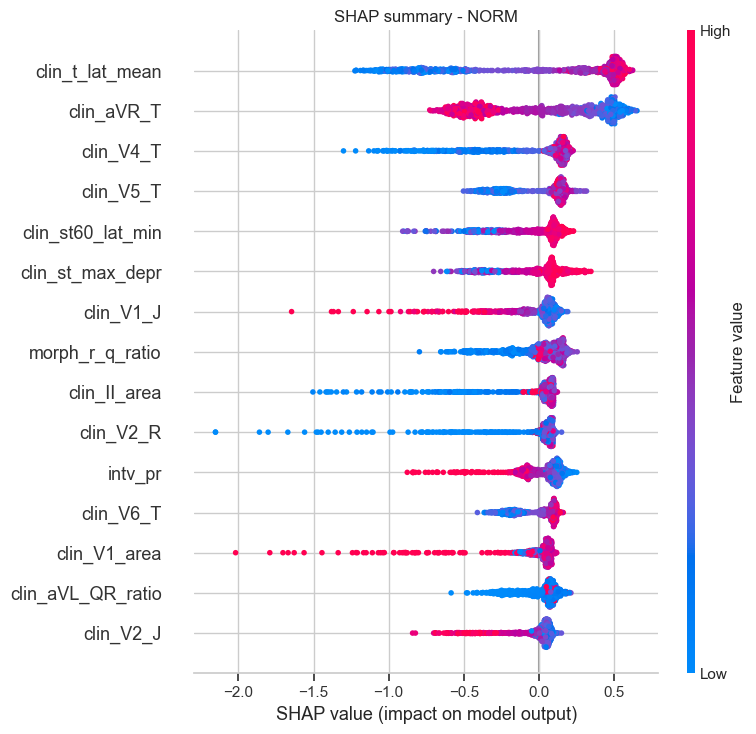

saved: ../outputs/v5_final\figures\13_shap_beeswarm_STTC.png


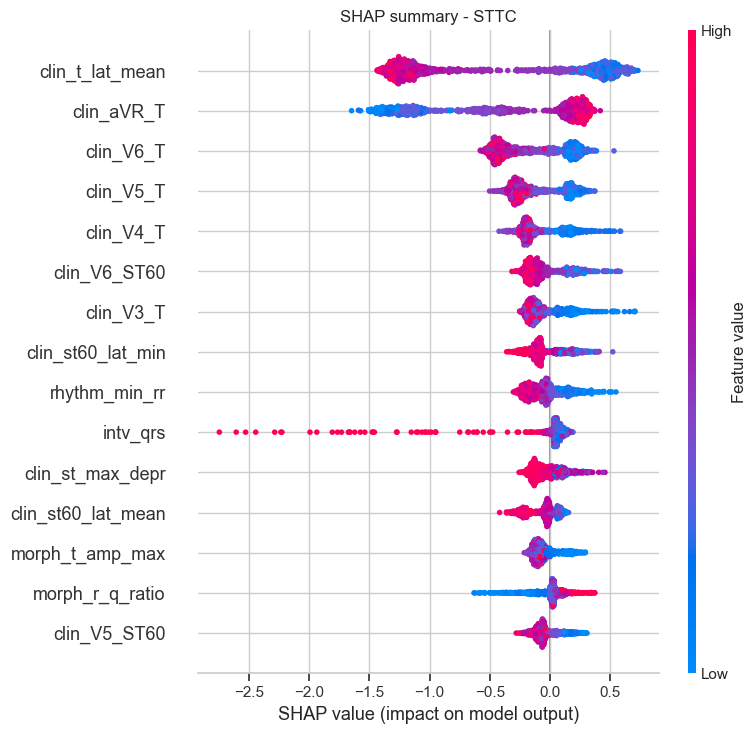

In [34]:
for c in CLASS_NAMES:
    plt.figure()
    shap.summary_plot(shap_values[c], shap_frames[c], max_display=15, show=False)
    plt.title(f"SHAP summary - {c}"); plt.tight_layout()
    save_fig(f"13_shap_beeswarm_{c}.png"); plt.show()


saved: ../outputs/v5_final\figures\14_shap_block_share.png


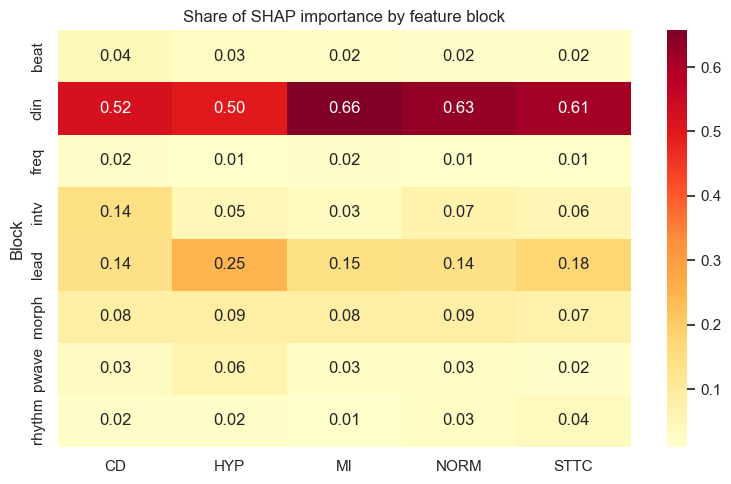

Rank of the expected clinical features inside each class (lower = more important):

  CD   : intv_qrs (#1), clin_qrs_axis_cos (#12), intv_qrs_sd (#26), clin_qrs_axis (#66), intv_qrs_refined_frac (#263)
  HYP  : clin_sokolow_lyon (#1), pwave_V1_neg (#7), pwave_V1_ptf (#8), pwave_II_pos (#9), clin_max_R_precordial (#32)
  MI   : clin_V2_R (#1), clin_t_lat_mean (#2), clin_aVF_QR_ratio (#3), clin_I_T (#4), clin_aVL_QR_ratio (#5)
  NORM : clin_t_lat_mean (#1), clin_aVR_T (#2), clin_V4_T (#3), clin_V5_T (#4), clin_st60_lat_min (#5)
  STTC : clin_t_lat_mean (#1), clin_aVR_T (#2), clin_V6_T (#3), clin_V5_T (#4), clin_V4_T (#5)


,Class,clinical share of top-10,best expected rank
0,CD,0.1,1
1,HYP,0.4,1
2,MI,0.9,1
3,NORM,0.9,1
4,STTC,0.8,1


In [35]:
# Share of total SHAP mass per feature block, per class
share = {}
for c in CLASS_NAMES:
    imp = top_tables[c]
    by_block = imp.groupby("Block")["Mean_abs_SHAP"].sum()
    share[c] = by_block / by_block.sum()
share_df = pd.DataFrame(share).fillna(0)
share_df.to_csv(os.path.join(TABLE_DIR, "shap_block_share.csv"))

plt.figure(figsize=(8, 5))
sns.heatmap(share_df, annot=True, fmt=".2f", cmap="YlOrRd")
plt.title("Share of SHAP importance by feature block"); plt.tight_layout()
save_fig("14_shap_block_share.png"); plt.show()

# Agreement with textbook criteria
EXPECTED = {
    "NORM": ["clin_", "intv_"],
    "MI":   ["clin_"],                                     # pathological Q, ST, R progression
    "STTC": ["clin_"],                                     # ST60/80, T amplitude
    "CD":   ["intv_qrs", "beat_qrs", "clin_qrs_axis"],     # QRS duration / width
    "HYP":  ["clin_sokolow", "clin_cornell", "clin_RV5", "clin_max_R", "clin_lewis", "clin_gubner", "clin_rvh", "clin_peguero", "pwave_"],
}
print("Rank of the expected clinical features inside each class (lower = more important):\n")
agree_rows = []
for c in CLASS_NAMES:
    order = top_tables[c]["Feature"].tolist()
    hits = [(f, order.index(f) + 1) for f in order if any(f.startswith(p) for p in EXPECTED[c])][:5]
    print(f"  {c:5s}: " + ", ".join(f"{f} (#{r})" for f, r in hits))
    agree_rows.append({"Class": c, "clinical share of top-10": np.mean(
        [any(f.startswith(p) for p in EXPECTED[c]) for f in order[:10]]), "best expected rank": hits[0][1] if hits else np.nan})
agree_df = pd.DataFrame(agree_rows)
agree_df.to_csv(os.path.join(TABLE_DIR, "shap_clinical_agreement.csv"), index=False)
display(agree_df.round(2))

## 13. Optional: seed variability of the selected model

Tree subsampling makes XGBoost slightly stochastic; a report should state the spread. The split is
fixed by the official folds, so only the model seed varies here. The study re-fits the **selected** model
for each seed, re-tunes the thresholds on fold 9 under the active policy and reports AUC, precision, recall and F1
(the classifier chain needs a few minutes per seed - lower `SEED_STUDY_SEEDS` if you are short of time).


In [36]:
RUN_SEED_STUDY = True
SEED_STUDY_SEEDS = [0, 1, 2]


def make_model_for_seed(name, seed):
    if name == "Logistic Regression":
        return OneVsRestClassifier(LogisticRegression(max_iter=5000, class_weight="balanced", random_state=seed))
    if name == "Random Forest":
        return OneVsRestClassifier(RandomForestClassifier(n_estimators=500, min_samples_leaf=2, class_weight="balanced_subsample",
                                                          random_state=seed, n_jobs=-1))
    if name == "XGBoost":
        return XGBMultiLabel(random_state=seed)
    return XGBClassifierChain(random_state=seed)


if RUN_SEED_STUDY:
    seed_rows = []
    for s in SEED_STUDY_SEEDS:
        m_ = make_model_for_seed(BEST, s)
        if isinstance(m_, XGBClassifierChain):
            m_.fit(Xtr_p, Y_tr, groups=PAT_TR)
        else:
            m_.fit(Xtr_p, Y_tr)
        pv_s, pt_s = m_.predict_proba(Xva_p), m_.predict_proba(Xte_p)
        th_s = (per_class_thresholds_precision_target(Y_va, pv_s, RECALL_FLOOR, RECALL_FLOOR_BY_CLASS)
                if THRESHOLD_POLICY == "precision_target" else per_class_thresholds(Y_va, pv_s))
        yh_s = (pt_s >= th_s).astype(int)
        seed_rows.append({"seed": s, "test macro AUC": macro_auc(Y_te, pt_s),
                          "test macro precision": precision_score(Y_te, yh_s, average="macro", zero_division=0),
                          "test macro recall": recall_score(Y_te, yh_s, average="macro", zero_division=0),
                          "test macro F1": f1_score(Y_te, yh_s, average="macro", zero_division=0)})
    seed_df = pd.DataFrame(seed_rows)
    seed_df.to_csv(os.path.join(TABLE_DIR, "seed_study.csv"), index=False)
    print(f"Seed study of the selected model: {BEST}")
    print(seed_df.round(4).to_string(index=False))
    print()
    for col in seed_df.columns[1:]:
        print(f"{col:22s}: {seed_df[col].mean():.4f} +/- {seed_df[col].std():.4f}")
else:
    seed_df = None


Seed study of the selected model: XGBoost
 seed  test macro AUC  test macro precision  test macro recall  test macro F1
    0          0.9260                0.7834             0.6612         0.7154
    1          0.9251                0.7896             0.6600         0.7168
    2          0.9247                0.7860             0.6581         0.7137

test macro AUC        : 0.9253 +/- 0.0006
test macro precision  : 0.7863 +/- 0.0031
test macro recall     : 0.6597 +/- 0.0016
test macro F1         : 0.7153 +/- 0.0015


## 14. Save the deployable bundle, inference function, run summary

Everything needed at inference time is stored as **one dictionary** (fitted preprocessor + model +
thresholds + feature names), so preprocessing and model can never drift apart.

> `XGBMultiLabel`, `XGBClassifierChain`, `MissingFilter`, `QuantileClipper` and `CorrelationPruner`
> are defined in this notebook. To load the bundle in a *different* script, copy those five classes
> into a module (e.g. `ecg_pipeline.py`) and import it before calling `joblib.load`.

In [37]:
bundle = {
    "preprocess": pre, "model": fitted[BEST], "model_name": BEST,
    "class_names": CLASS_NAMES,
    "threshold_policy": THRESHOLD_POLICY, "recall_floor": RECALL_FLOOR, "recall_floor_by_class": RECALL_FLOOR_BY_CLASS,
    "thresholds": [float(t) for t in ACTIVE_THRESHOLDS[BEST]],           # thresholds under the ACTIVE policy
    "thresholds_f1": [float(t) for t in THRESHOLDS[BEST]],
    "thresholds_precision_target": [float(t) for t in THRESHOLDS_PRECISION[BEST]],
    "feature_names_in": list(X_all.columns), "feature_names_model": FEAT_NAMES,
    "sampling_rate": SAMPLING_RATE, "use_demographics": USE_DEMOGRAPHICS,
    "feature_version": FEATURE_VERSION, "sklearn_version": sklearn.__version__,
}
BUNDLE_PATH = os.path.join(OUTPUT_DIR, "ecg_model_bundle.pkl")
joblib.dump(bundle, BUNDLE_PATH)
bundle = joblib.load(BUNDLE_PATH)                       # round-trip check
print("Saved and reloaded:", BUNDLE_PATH)


def predict_ecg(signal, age=None, sex=None, bundle=bundle):
    # signal: (5000, 12) array in mV at 500 Hz, standard PTB-XL lead order. Returns a per-class table.
    f, _ = extract_complete_features(signal, bundle["sampling_rate"])
    if bundle["use_demographics"]:
        f["demo_age"] = np.nan if age is None else float(age)
        f["demo_sex"] = np.nan if sex is None else float(sex)
    row = pd.DataFrame([f]).reindex(columns=bundle["feature_names_in"]).replace([np.inf, -np.inf], np.nan)
    proba = bundle["model"].predict_proba(bundle["preprocess"].transform(row))[0]
    thr = np.asarray(bundle["thresholds"])
    return pd.DataFrame({"class": bundle["class_names"], "probability": proba.round(3),
                         "threshold": thr.round(2), "predicted": (proba >= thr).astype(int)})


# Demo on three test-fold records
test_ids = ecg_ids[te][:3]
for eid in test_ids:
    rec = clean_metadata[clean_metadata["ecg_id"] == eid].iloc[0]
    print(f"\necg_id {eid} | true label(s): {rec['diagnostic_superclass']}")
    display(predict_ecg(load_ecg(rec), age=rec["age"], sex=rec["sex"]))

Saved and reloaded: ../outputs/v5_final\ecg_model_bundle.pkl

ecg_id 9 | true label(s): ['NORM']


,class,probability,threshold,predicted
0,CD,0.023,0.70,0
1,HYP,0.003,0.42,0
2,MI,0.007,0.63,0
3,NORM,0.977,0.88,1
4,STTC,0.002,0.68,0



ecg_id 38 | true label(s): ['NORM']


,class,probability,threshold,predicted
0,CD,0.498,0.70,0
1,HYP,0.003,0.42,0
2,MI,0.180,0.63,0
3,NORM,0.624,0.88,0
4,STTC,0.015,0.68,0



ecg_id 40 | true label(s): ['NORM']


,class,probability,threshold,predicted
0,CD,0.205,0.70,0
1,HYP,0.037,0.42,0
2,MI,0.035,0.63,0
3,NORM,0.909,0.88,1
4,STTC,0.007,0.68,0


In [38]:
summary = {
    "feature_version": FEATURE_VERSION, "random_state": RANDOM_STATE, "sampling_rate": SAMPLING_RATE,
    "versions": {"python": sys.version.split()[0], "numpy": np.__version__, "pandas": pd.__version__,
                 "sklearn": sklearn.__version__, "neurokit2": nk.__version__, "wfdb": wfdb.__version__},
    "n_records_metadata": int(len(metadata)), "n_records_labeled": int(len(clean_metadata)),
    "n_records_features": int(len(X_full)), "n_extraction_failures": int(len(failures)),
    "class_names": CLASS_NAMES,
    "split": {"train_folds_1_8": int(tr.sum()), "val_fold_9": int(va.sum()), "test_fold_10": int(te.sum())},
    "n_features_extracted": int(X_all.shape[1]), "n_features_after_preprocessing": int(len(FEAT_NAMES)),
    "use_demographics": USE_DEMOGRAPHICS, "min_likelihood": MIN_LIKELIHOOD,
    "selected_model": BEST,
    "selection_rule": f"simplest model within {SELECTION_TOL} of the best validation (fold 9) macro AUC",
    "chain_inner_cv": "patient-grouped StratifiedGroupKFold",
    "threshold_policy": THRESHOLD_POLICY, "recall_floor": RECALL_FLOOR,
    "thresholds_tuned_on": "validation fold (9), per class, both F1-optimal and precision-targeted",
    "model_comparison": results_df.to_dict(orient="records"),
    "per_class": per_class_df.to_dict(orient="records"),
    "threshold_policy_comparison": compare_df.to_dict(orient="records"),
    "headline_test_metrics": headline,
    "seed_study": None if seed_df is None else seed_df.to_dict(orient="records"),
}
with open(os.path.join(OUTPUT_DIR, "run_summary.json"), "w") as fh:
    json.dump(summary, fh, indent=2, default=float)

print("Everything written to", os.path.abspath(OUTPUT_DIR))
for root, _, files in os.walk(OUTPUT_DIR):
    if "cache_" in root:
        continue
    for fn in sorted(files):
        print("  ", os.path.relpath(os.path.join(root, fn), OUTPUT_DIR))

Everything written to c:\Users\USER\Desktop\ECG_Clinical_Decision_Support_System\outputs\v5_final
   ecg_model_bundle.pkl
   features_raw.csv
   run_summary.json
   figures\01_metadata_eda.png
   figures\02_label_eda.png
   figures\03_example_12_lead.png
   figures\04_delineation_check.png
   figures\05_example_per_class.png
   figures\06_missingness.png
   figures\07_key_features_by_class.png
   figures\08_key_feature_correlation.png
   figures\09_roc_pr_curves.png
   figures\10_confusion_matrices.png
   figures\11_model_comparison.png
   figures\12_ablation.png
   figures\13_shap_beeswarm_CD.png
   figures\13_shap_beeswarm_HYP.png
   figures\13_shap_beeswarm_MI.png
   figures\13_shap_beeswarm_NORM.png
   figures\13_shap_beeswarm_STTC.png
   figures\14_shap_block_share.png
   shap\CD_shap_importance.csv
   shap\HYP_shap_importance.csv
   shap\MI_shap_importance.csv
   shap\NORM_shap_importance.csv
   shap\STTC_shap_importance.csv
   tables\ablation.csv
   tables\extraction_failures.cs

## 15. What goes into the report

**Methods**
* Data: PTB-XL v1.0.3, 500 Hz records, labelled records only, five diagnostic superclasses
  (SCP likelihood threshold `MIN_LIKELIHOOD`).
* Split: official `strat_fold` — folds 1–8 train, 9 validation, 10 test; patient-disjoint (asserted in the code).
* Signal processing: NeuroKit2 cleaning, R-peak detection and DWT delineation on lead II (fallback I, V5);
  QRS onset/offset re-measured on the 12-lead spatial velocity; fiducial points transferred to all leads;
  every measurement gated to a physiological range.
* Features: rhythm, per-beat rate-corrected intervals, per-lead clinical criteria, P-wave block, lead II morphology,
  spectrum, per-lead statistics (counts in `run_summary.json`).
* Preprocessing: missingness filter, median imputation, constant removal, percentile clipping, correlation
  pruning (|r| > 0.95), standardisation — all fitted on training folds only.
* Models: LR, RF, XGBoost and an out-of-fold (patient-grouped) probabilistic XGBoost classifier chain, all with
  class-imbalance weighting; model selection on fold 9 with a simplicity tolerance. Per-class thresholds tuned on fold 9
  under two policies (F1-optimal, and precision-targeted: highest threshold keeping recall >= `RECALL_FLOOR`, never below
  the F1-optimal threshold); the active policy is `THRESHOLD_POLICY`.

**Results** (files in `tables/` and `figures/`): `headline_metrics.json` (macro / micro precision, recall, F1, per-label
accuracy, balanced accuracy, exact-match accuracy, AUC, Fmax), `model_comparison.csv` (test macro AUC with patient-level
bootstrap CI), `per_class_results.csv`, `threshold_policy_comparison.csv`, `ablation.csv`, `shap_clinical_agreement.csv`,
`seed_study.csv`, `feature_plausibility_norm_only.csv`, ROC/PR curves, confusion matrices, SHAP figures.

**How to read the accuracy numbers.** Per-label accuracy is inflated for rare classes (a model that never predicts HYP
is still ~88 % "accurate" on HYP), and exact-match accuracy is a very strict measure for a multi-label task. Lead with
macro AUC, then precision / recall / F1 per class; report accuracy only as a secondary figure.

**Framing.** "XGBoost on hand-crafted ECG features" is not novel by itself, and PTB-XL+ (Strodthoff et al.,
Scientific Data 2023) already ships pre-extracted feature sets. Defensible contributions are the fully
open-source, reproducible pipeline with an honest gap to deep-learning baselines, the block ablation that
quantifies what the clinical features add, the audit-driven corrections (QRS extraction, threshold policy, patient-grouped
chain) and the SHAP-vs-textbook agreement analysis.

**Known limitations to state**
* Single dataset; no external validation (CPSC2018 or Chapman-Shaoxing would be the next step).
* Delineation is automatic and lead-II based; the QRS limits are checked only by plausibility on NORM-only records,
  not against manual annotation.
* HYP is a heterogeneous superclass (ventricular hypertrophy plus atrial enlargement); its precision remains the weakest
  of the five classes.
* Records for which delineation failed are excluded (`extraction_failures.csv` lists them).
* Superclass labels come from a mix of cardiologist annotation and device-generated statements.
* Research prototype, not a medical device.
